<h1>Predicting Rain in Australia</h1>

<h2>Table of Contents</h2>
<ul>
  <li><a href="#section1">1. Project Description</a></li>
  <li><a href="#section2">2. Data Understanding</a></li>
  <li><a href="#section3">3. Exploratory Data Analysis (EDA)</a></li>
  <li><a href="#section4">4. Data Preprocessing</a></li>
  <li><a href="#section5">5. Model Selection and Hyperparameter Tuning</a></li>
  <li><a href="#section6">6. Final Models Training & Evaluation</a></li>
  <li><a href="#section7">7. Feature Importance / Explainability</a></li>
  <li><a href="#section8">8. Conclusions & Next Steps</a></li>
</ul>

<a id='section1'></a>
## 1. Project Description

**Domain and Data Understanding**

The dataset our group uses is called “Rain in Australia.” It originates from the Australian Bureau of Meteorology and comprises about 10 years (2007–2017) of daily weather observations from locations across Australia. The data were collected from multiple weather stations and are openly accessible online (http://www.bom.gov.au/climate/data). The dataset consists of 23 attributes and approximatly 145,000 observations, including both numerical and categorical variables. Example feature groups include date and location, temperature, rainfall and related indicators, humidity, pressure, wind, and cloud cover. The main target variable (the last column) is RainTomorrow, which indicates whether it will rain on the following day. Several variables contain a substantial amount of missing values, which we will need to address during data cleaning.

**Project Statement and Goals**

Predicting rain in Australia is crucial for several reasons. Accurate rainfall forecasts are essential for planning daily activities and managing city operations, making life more predictable and convenient (Sarasa-Cabezuelo, 2022). The farming and food sectors highly depend on rainfall for planting, scheduling, and crop protection (Banik & Biswas, 2025). Because these sectors provide basic necessities for survival, farmers need to have accurate data to plan and react to upcoming weather.

Rainfall data are also important for predicting and managing extreme hydrological events (Lettenmaier, 2024). Understanding rainfall trends helps with the future prevention of flood risk and drought. Australia is a country with high climate variability; its rainfall is characterized by periods of extremely heavy rain and drought. For example, it experienced its driest 24-month period on record in the lead-up to the end of June 2020. Such a climate has strong impacts on both the environment and society (ARC Centre of Excellence for Climate Extremes, 2022).

Based on the reasons above, our main research question is:

**Given today’s weather conditions at a specific Australian location, can we predict whether it will rain tomorrow?**

We treat this as a supervised binary classification problem, where the target variable RainTomorrow indicates whether at least 1 mm of rain will fall on the following day. We also aim to identify which variables most strongly influence this dependent variable and, if necessary, to build new features by combining existing ones.

Our project consists of the following goals:
1. Understand and prepare data - Exploratory data analysis, handle missing data, and conduct additional features for later analysis
2. Build, train, and compare several machine learning models
3. Evaluate and compare model performances using suitable classification metrics
4. Interpret results and identify key weather variables strongly associated with the targeted variable

<a id='section2'></a>
## 2. Data Understanding

### 2.1 Loading Data and imports

In [ ]:
# Installing needed packages
!pip install numpy pandas matplotlib seaborn folium geopy scikit-learn category-encoders lightgbm scipy

In [2]:
# CORE LIBRARIES
import numpy as np
import pandas as pd
import time

# DATA VISUALIZATION
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import folium
from geopy.geocoders import Nominatim

from typing import Iterable, Optional, Tuple

# DATA PREPROCESSING
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# MODEL SELECTION & SPLITTING
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict
)

# MACHINE LEARNING MODELS
from sklearn.ensemble import (
    RandomForestClassifier,
    IsolationForest,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

# METRICS
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    roc_auc_score,
    accuracy_score,
    make_scorer
)

# OTHER UTILITIES
from scipy import stats
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)



In [3]:
df = pd.read_csv('weatherAUS.csv')
print(df.head())

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7    

### 2.2 Inspecting Data Frame

In [4]:
# Number of observation and variables
nRows, nCols = df.shape
df.shape

(145460, 23)

In [5]:
# Checking if there are duplicated rows
df.duplicated().sum()

np.int64(0)

#### Target Variable
RainTomorrow is a binary variable: Yes or No.

In [6]:
target = 'RainTomorrow'
print('Target:', target)

Target: RainTomorrow


#### Features

In [7]:
# Shows the features
print('Features: ', [col for col in df.columns if col != 'RainTomorrow'])

Features:  ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']


> Aissata: paste data description table describing every feature.

In [8]:
# Checks the data types of features and target
df.dtypes

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

#### Descriptive Statistics

In [9]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


#### Checking Features Data Type

In [10]:
def inspect_dataframe(df, top_n=5):
    summary = []

    for col in df.columns:
        series = df[col]
        dtype = series.dtype
        
        # Cardinality
        cardinality = series.nunique(dropna=True)
        
        # Most common values
        common_vals = series.value_counts(dropna=False).head(top_n)
        
        # Heuristic: numeric or categorical?
        if pd.api.types.is_numeric_dtype(series):
            inferred_type = "numeric"
        elif pd.api.types.is_datetime64_any_dtype(series):
            inferred_type = "datetime"
        else:
            # For object/string columns, check cardinality ratio
            ratio = cardinality / len(series)
            inferred_type = "categorical" if ratio < 0.5 else "high‑cardinality text"
        
        summary.append({
            "column": col,
            "dtype": str(dtype),
            "cardinality": cardinality,
            "inferred_type": inferred_type,
            "most_common": common_vals.to_dict()
        })

    return pd.DataFrame(summary)

inspect_dataframe(df)


,column,dtype,cardinality,inferred_type,most_common
0,Date,object,3436,categorical,"{'2013-11-12': 49, '2014-09-01': 49, '2014-08-..."
1,Location,object,49,categorical,"{'Canberra': 3436, 'Sydney': 3344, 'Darwin': 3..."
2,MinTemp,float64,389,numeric,"{nan: 1485, 11.0: 899, 10.2: 898, 9.6: 896, 10..."
3,MaxTemp,float64,505,numeric,"{nan: 1261, 20.0: 885, 19.0: 843, 19.8: 840, 2..."
4,Rainfall,float64,681,numeric,"{0.0: 91080, 0.2: 8761, 0.4: 3782, nan: 3261, ..."
5,Evaporation,float64,358,numeric,"{nan: 62790, 4.0: 3339, 8.0: 2609, 2.2: 2095, ..."
6,Sunshine,float64,145,numeric,"{nan: 69835, 0.0: 2359, 10.7: 1101, 11.0: 1094..."
7,WindGustDir,object,16,categorical,"{nan: 10326, 'W': 9915, 'SE': 9418, 'N': 9313,..."
8,WindGustSpeed,float64,67,numeric,"{nan: 10263, 35.0: 9215, 39.0: 8794, 31.0: 842..."
9,WindDir9am,object,16,categorical,"{'N': 11758, nan: 10566, 'SE': 9287, 'E': 9176..."


Most features data type seem to be correct, except for Cloud9am and Cloud3pm.

In [11]:
print(df["Cloud9am"])
print(df["Cloud3pm"])

0         8.0
1         NaN
2         NaN
3         NaN
4         7.0
         ... 
145455    NaN
145456    NaN
145457    NaN
145458    3.0
145459    8.0
Name: Cloud9am, Length: 145460, dtype: float64
0         NaN
1         NaN
2         2.0
3         NaN
4         8.0
         ... 
145455    NaN
145456    NaN
145457    NaN
145458    2.0
145459    8.0
Name: Cloud3pm, Length: 145460, dtype: float64


We can clearly see that Cloud is a ordinal variable. We thus describe our variables as such:

In [12]:
# Changing Cloud data types
df[["Cloud9am", "Cloud3pm"]] = df[["Cloud9am", "Cloud3pm"]].astype(object)

# Checking the data types again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

### 2.3 Definition of General Variables

In [13]:
target = 'RainTomorrow'
features = [col for col in df.columns if col != target]

numerical_features = [col for col in df.columns if col in features and df[col].dtype == 'float64']

categorical_features = [col for col in df.columns if col in features and col not in numerical_features]
# Removing date as categorical feature
if "Date" in categorical_features:
    categorical_features.remove("Date")


ordinal_categorical_features = ['Cloud3pm', 'Cloud9am']
nominal_categorical_features = list(set(categorical_features) - set(ordinal_categorical_features))

print('Target variable: ', target)
print('All features: ', features)
print('Numerical features: ', numerical_features)
print('Categorical features: ', categorical_features)
print('Ordinal categorical features: ', ordinal_categorical_features)
print('Nominal categorical features: ', nominal_categorical_features)

Target variable:  RainTomorrow
All features:  ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']
Numerical features:  ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']
Categorical features:  ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'Cloud9am', 'Cloud3pm', 'RainToday']
Ordinal categorical features:  ['Cloud3pm', 'Cloud9am']
Nominal categorical features:  ['Location', 'WindGustDir', 'WindDir3pm', 'WindDir9am', 'RainToday']


#### Helper Function

In [14]:
def evaluate_model(model_name, y_true, y_pred):
    # Detect positive class
    positive_label = 1 if y_true.dtype != object else "Yes"

    metrics = {
        "Model": model_name,
        "F1": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "BalancedAccuracy": balanced_accuracy_score(y_true, y_pred)
    }

    return metrics


<a id='section3'></a>
## 3. Exploratory Data Analysis (EDA)

We start Explorator Data Analysis (EDA) by exploring distribution, patterns and relationships between the variables.

In [15]:
# Copying the data frame to keep the original data. In the following section we use df_eda only.
df_eda = df.copy()

#### Encoding Categorical Variables


In [16]:
def to_binary_yes_no(s: pd.Series) -> pd.Series:
    """Convert Yes/No-like series to 1/0; preserve numeric if already numeric."""
    if s.dtype == "O":
        return (
            s.astype(str)
             .str.strip()
             .str.lower()
             .map({"yes": 1, "no": 0})
        )
    return pd.to_numeric(s, errors="coerce")

# Date parsing + time features
df_eda["Date"] = pd.to_datetime(df_eda["Date"], errors="coerce")
df_eda["Month"] = df_eda["Date"].dt.month
df_eda["Year"] = df_eda["Date"].dt.year

# Binary targets used throughout EDA
df_eda["RainTomorrow_bin"] = to_binary_yes_no(df_eda["RainTomorrow"])
df_eda["RainToday_bin"] = to_binary_yes_no(df_eda["RainToday"])

# --- Constants ---
MONTH_POSITIONS = list(range(1, 13))
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

WIND_DIR_ORDER = [
    "N","NNE","NE","ENE",
    "E","ESE","SE","SSE",
    "S","SSW","SW","WSW",
    "W","WNW","NW","NNW"
]

CLOUD_TEXT_ORDER = [
    "Clear sky","Almost clear","Mostly clear","Partly cloudy","Half cloudy",
    "Mostly cloudy","Very cloudy","Nearly overcast","Overcast"
]


#### Helper Functions for EDA

In [17]:
# Nils Becker (03817505)

# Function for boxplot matrix,
def boxplot_matrix(df, nCols, nRows):
    num = df_eda[numerical_features] # Only keeps numerical features, since boxplots are not for ordinal data.

    plt.figure(figsize=(8 * nCols, 6 * nRows)) # Creates dimensions for figure size dependent from matrix size.
    for i, col in enumerate(num.columns, 1):
        plt.subplot(nRows, nCols, i) # Creates one boxplot in each subplot.
        plt.boxplot(num[col].dropna()) # Drops NaN Value, since boxplots can't handle them.
        plt.title(col)

    plt.show()

# Function for categorical target variable report. It shows the missingness and a plot with percentage labels.
def univariate_target_report(df, target):
    n = len(df)
    missing = df[target].isna().sum()

    # Counts and calculates percentages of missing values.
    target_counts = df[target].value_counts(dropna=False)
    target_pct = (target_counts / n * 100).round(2)

    print(f"=== Target report: {target} ===")
    print(f"Rows: {n}")
    print(f"Missing: {missing} ({missing / n * 100:.2f}%)\n")
    print("Counts:")
    print(target_counts)
    print("\nPercentages:")
    print(target_pct.astype(str) + "%")

    # Creates a plot with percentage labels.
    plt.figure(figsize=(6, 6))
    ax = sns.countplot(x=target, data=df, order=target_counts.index)

    # Finds the correct position of the label and places the number above the bar.
    for bar in ax.patches:
        count = bar.get_height()
        pct = count / n * 100
        ax.annotate(
            f"{pct:.1f}%",
            (bar.get_x() + bar.get_width() / 2, count),
            ha="center",
            va="bottom"
        )

    # Formats the plot.
    plt.title(f"Distribution of Rain Tomorrow")
    plt.xlabel("Rain Tomorrow")
    plt.ylabel("Number of observations")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


# Function for EDA of numerical features. Returns number of data points, missing values and plot, descriptive statistics, skewness,
def univariate_report_numerical(df, col, target=None, bins=30):
    # convert column to numerical
    s = pd.to_numeric(df[col], errors="coerce")

    n = len(s)
    missing = s.isna().sum()

    print(f"=== {col} (numeric) ===")
    print(f"Rows: {n}")
    print(f"Missing: {missing} ({missing / n * 100:.1f}%)")

    # basic statistics
    desc = s.describe()
    print("\nDescriptive statistics:")
    print(desc)

    # skewness
    skew = s.skew()
    print(f"\nSkewness: {skew:.2f}")

    # missingness plot
    plt.figure(figsize=(4, 2))
    plt.bar(["non-missing", "missing"], [n - missing, missing])
    plt.title(f"Missingness: {col}")
    plt.tight_layout()
    plt.show()

    # histogram
    plt.figure(figsize=(8, 3))
    plt.hist(s.dropna(), bins=bins)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # boxplot
    plt.figure(figsize=(8, 1.8))
    sns.boxplot(x=s.dropna())
    plt.title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

    # IQR outlier analysis
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        print("IQR is zero → outlier detection not meaningful.")
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_share = ((s < lower) | (s > upper)).mean() * 100
        print(f"Outliers (IQR rule): {outlier_share:.1f}%")

    # optional target split
    if target is not None and target in df.columns:
        tmp = df[[col, target]].copy()
        tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
        tmp = tmp.dropna()

        if len(tmp) > 0:
            plt.figure(figsize=(8, 3))
            sns.histplot(
                data=tmp,
                x=col,
                hue=target,
                bins=bins,
                element="step",
                stat="count"
            )
            plt.title(f"{col} split by {target}")
            plt.tight_layout()
            plt.show()

# Function for EDA of categorical features. Returns number of data points, missing values and plot, descriptive statistics, skewness,
def univariate_report_categorical(df, col, top_k=10):
    s = df[col].astype("string")

    n = len(s)
    missing = s.isna().sum()

    print(f"=== {col} (categorical) ===")
    print(f"Rows: {n}")
    print(f"Missing: {missing} ({missing / n * 100:.1f}%)")
    print(f"Unique values: {s.nunique(dropna=False)}")

    vc = s.value_counts(dropna=False).head(top_k)
    print(f"\nTop {top_k} categories:")
    print(vc)

    plt.figure(figsize=(8, 3))
    sns.countplot(
        x=df[col],
        order=df[col].value_counts(dropna=False).head(top_k).index
    )
    plt.title(f"Top categories: {col}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()




# Converts a location name into geographic coordinates (latitude, longitude). Returns a series with latitude and longitude, or None values if the location cannot be found.
# location (str): Name of the location to be geocoded.
# county (str): Country context is added to improve the accuracy, but held constant as 'Australia'
# sleep (int): Pause in seconds between requests to avoid server overload (according to documentation).

def get_geocode(location, country="Australia", sleep=1):
    loc = geolocator.geocode(f"{location}, {country}") # Query the Nominatim service using a string with the location and country context.
    time.sleep(sleep)  # Pause execution to respect the rate limits.

    # If the location cannot be geocoded return None.
    if loc is None:
        return pd.Series({"Latitude": None, "Longitude": None})

    # Return the found latitude and longitude.
    return pd.Series({"Latitude": loc.latitude, "Longitude": loc.longitude})

In [77]:
def rain_rate_by_category(
    df: pd.DataFrame,
    cat_col: str,
    target_col: str = "RainTomorrow_bin",
    order: Optional[Iterable] = None,
    top_n: Optional[int] = None,
    ) -> pd.DataFrame:
    """Count + RainTomorrow rate by category."""
    tmp = df[[cat_col, target_col]].dropna()
    out = (
        tmp.groupby(cat_col)[target_col]
           .agg(count="size", rain_rate="mean")
           .sort_values("count", ascending=False)
    )
    if top_n is not None:
        out = out.head(top_n)
    if order is not None:
        out = out.reindex(list(order))
    return out.reset_index()

def _annotate_min_max_bars(ax, values, fmt="{:.1f}%"):
    """Annotate only min & max bar values."""
    if len(values) == 0:
        return
    values = np.asarray(values, dtype=float)
    i_min, i_max = int(np.nanargmin(values)), int(np.nanargmax(values))
    bars = ax.patches
    for i in {i_min, i_max}:
        b = bars[i]
        ax.text(
            b.get_x() + b.get_width() / 2,
            values[i],
            fmt.format(values[i]),
            ha="center",
            va="bottom" if i == i_max else "top",
            fontsize=10,
            fontweight="bold",
            color="darkgreen" if i == i_max else "darkred",
        )

def plot_rate_bar(
    rate_df: pd.DataFrame,
    x_col: str,
    rate_col: str = "rain_rate",
    title: str = "",
    xlabel: str = "",
    ylabel: str = "RainTomorrow rate (%)",
    rotate: int = 45,
    figsize: Tuple[int, int] = (12, 6),
    annotate_min_max: bool = True,
    ):
    """Simple bar chart for rates (0–1 or 0–100)."""
    d = rate_df.copy()
    y = d[rate_col].astype(float)
    if y.max() <= 1.01:
        y = y * 100

    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.bar(d[x_col].astype(str), y.values)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=rotate, ha="right")

    if annotate_min_max:
        _annotate_min_max_bars(ax, y.values)

    plt.tight_layout()
    plt.show()

def polar_rain_rate(ax, df: pd.DataFrame, dir_col: str, order: Iterable, title: str):
    """Polar bar chart: RainTomorrow rate (%) by wind direction."""
    tmp = df[[dir_col, "RainTomorrow_bin"]].dropna()
    rate_pct = (
        tmp.groupby(dir_col)["RainTomorrow_bin"]
           .mean()
           .reindex(list(order))
           .fillna(0)
           .mul(100)
           .values
    )

    n = len(order)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    width = 2*np.pi / n

    ax.bar(angles, rate_pct, width=width, align="center", alpha=0.85)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels(list(order), fontsize=9)
    ax.set_title(title, fontsize=13, pad=18)
    ax.set_yticklabels([])

    # annotate only min/max
    i_min, i_max = int(np.argmin(rate_pct)), int(np.argmax(rate_pct))
    for i, col in [(i_min, "darkred"), (i_max, "darkgreen")]:
        ax.text(
            angles[i],
            rate_pct[i] + 1.5,
            f"{rate_pct[i]:.1f}%",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color=col
        )

def plot_cloud_rate(ax, df: pd.DataFrame, cloud_col: str, title: str):
    """Bar chart: RainTomorrow rate (%) by cloud (numeric 0–8 or text buckets)."""
    d = df[[cloud_col, "RainTomorrow_bin"]].dropna().copy()
    cloud_num = pd.to_numeric(d[cloud_col], errors="coerce")

    if cloud_num.notna().mean() > 0.8:
        d[cloud_col] = cloud_num
        order = list(range(0, 9))
        x = order
        rate_pct = (
            d.groupby(cloud_col)["RainTomorrow_bin"]
             .mean()
             .reindex(order)
             .mul(100)
        )
        bars = ax.bar(x, rate_pct.values)
        ax.set_xticks(x)
        ax.set_xlabel(f"{cloud_col} (0–8 oktas)")
    else:
        order = CLOUD_TEXT_ORDER
        rate_pct = (
            d.groupby(cloud_col)["RainTomorrow_bin"]
             .mean()
             .reindex(order)
             .dropna()
             .mul(100)
        )
        bars = ax.bar(rate_pct.index.astype(str), rate_pct.values)
        ax.tick_params(axis="x", rotation=30)
        ax.set_xlabel(cloud_col)

    ax.set_title(title, fontsize=13)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.grid(axis="y", alpha=0.3)

    # annotate only min/max
    if len(rate_pct) > 0:
        i_min, i_max = int(np.nanargmin(rate_pct.values)), int(np.nanargmax(rate_pct.values))
        offset = float(np.nanmax(rate_pct.values)) * 0.01
        for i, col in [(i_min, "darkred"), (i_max, "darkgreen")]:
            ax.text(
                bars[i].get_x() + bars[i].get_width() / 2,
                rate_pct.values[i] + offset,
                f"{rate_pct.values[i]:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color=col,
            )

def binned_rate_curve(
    df: pd.DataFrame,
    feature: str,
    target_col: str = "RainTomorrow_bin",
    q: int = 10,
    ) -> pd.DataFrame:
    """Return binned rate curve with x-midpoint + rate (%)."""
    d = df[[feature, target_col]].copy()
    d[feature] = pd.to_numeric(d[feature], errors="coerce")
    d[target_col] = pd.to_numeric(d[target_col], errors="coerce")
    d = d.dropna()
    if d.empty or d[feature].nunique() <= 1:
        return pd.DataFrame(columns=["x_mid", "rate_pct"])

    if feature.lower() == "rainfall":
        upper = max(float(d[feature].max()), 20.0)
        bins = [-0.1, 0, 1, 5, 20, upper]
        d["bin"] = pd.cut(d[feature], bins=bins, include_lowest=True)
    else:
        d["bin"] = pd.qcut(d[feature], q=q, duplicates="drop")

    rate = (
        d.groupby("bin")[target_col]
         .mean()
         .mul(100)
         .reset_index(name="rate_pct")
    )
    rate["x_mid"] = rate["bin"].apply(lambda b: (b.left + b.right) / 2)
    return rate[["x_mid", "rate_pct"]]

def plot_rate_curve(ax, curve_df: pd.DataFrame, title: str):
    if curve_df.empty:
        ax.set_title(f"{title} (insufficient data)")
        ax.axis("off")
        return

    ax.plot(curve_df["x_mid"], curve_df["rate_pct"], marker="o", linewidth=2)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("RainTomorrow rate (%)", fontsize=10)
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 100)

    # annotate min/max
    i_min = int(curve_df["rate_pct"].idxmin())
    i_max = int(curve_df["rate_pct"].idxmax())
    for i, dy, col in [(i_max, 6, "darkgreen"), (i_min, -12, "darkred")]:
        ax.annotate(
            f"{curve_df.loc[i, 'rate_pct']:.1f}%",
            (curve_df.loc[i, "x_mid"], curve_df.loc[i, "rate_pct"]),
            textcoords="offset points",
            xytext=(0, dy),
            ha="center",
            fontsize=10,
            fontweight="bold",
            color=col,
        )

def plot_rate_curves_grid(
    df: pd.DataFrame,
    features: Optional[Iterable[str]] = None,
    target_col: str = "RainTomorrow_bin",
    q: int = 10,
    n_cols: int = 4,
    figsize: Tuple[int, int] = (30, 15),
    suptitle: str = "RainTomorrow Rate by Numerical Features",
    ):
    """Grid of binned rate curves for numeric features."""
    if features is None:
        features = [
            c for c in df.select_dtypes(include=[np.number]).columns
            if c not in {target_col, "RainToday_bin"}
        ]
    features = list(features)

    curves = [(f, binned_rate_curve(df, f, target_col=target_col, q=q)) for f in features]
    curves = [(f, c) for f, c in curves if not c.empty]

    n_plots = len(curves)
    n_rows = int(np.ceil(n_plots / n_cols)) if n_plots else 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(n_rows, n_cols)

    for i, (feat, curve) in enumerate(curves):
        ax = axes[i // n_cols, i % n_cols]
        plot_rate_curve(ax, curve, feat)

    for j in range(n_plots, n_rows * n_cols):
        axes[j // n_cols, j % n_cols].axis("off")

    fig.suptitle(suptitle, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def folium_bubble_map(
    df: pd.DataFrame,
    lat_col: str,
    lon_col: str,
    size_col: str,
    popup_col: str,
    location: Tuple[float, float] = (-25.2744, 133.7751),
    zoom_start: int = 5,
    radius_range: Tuple[int, int] = (4, 30),
    ):
    """Folium bubble map with size normalized from size_col."""
    d = df.dropna(subset=[lat_col, lon_col, size_col]).copy()
    if d.empty:
        return folium.Map(location=list(location), zoom_start=zoom_start)

    scaler = MinMaxScaler(feature_range=radius_range)
    d["_radius_"] = scaler.fit_transform(d[[size_col]])

    m = folium.Map(location=list(location), zoom_start=zoom_start)
    for _, row in d.iterrows():
        folium.CircleMarker(
            location=[row[lat_col], row[lon_col]],
            radius=float(row["_radius_"]),
            fill=True,
            fill_opacity=0.7,
            weight=1,
            popup=str(row[popup_col]),
        ).add_to(m)
    return m

#### Location Geocoding

This sections translates the categorical location information in the dataset into geograpich coordinates (Latitude, Longitude). Using the online OpenStreetMap Nominatim geocoding service, each location name is parsed as a string and mapped to a corresponding latitude and longitude. This step enables spatial analysis and visualization of feature and target patterns across Australia by linking meterological observations to their physical locations. The application can be found in bivariate analysis. A new CSV including location (str), latitude (str), and longitude (str) is saved in case the server query times out.


In [78]:
# Nils Becker (03817505)

# Aggregates rainfall by location into dataframe and resets index.
df_geocodes = df_eda.groupby("Location", as_index=False)["Rainfall"].mean()

# Apply the geocoding function to each location in the data frame and store the results in new columns.
df_geocodes[["Latitude", "Longitude"]] = (
    df_geocodes["Location"]
    .astype(str)
    .apply(get_geocode)
)
# Saves the data frame locally, in case the server rejects the query
df_geocodes.to_csv('df_geocodes.csv', index=False)

df_geocodes

,Location,Rainfall,Latitude,Longitude
0,Adelaide,1.566354,-34.928181,138.599931
1,Albany,2.263859,-35.024782,117.883608
2,Albury,1.914115,-36.080477,146.916280
3,AliceSprings,0.882850,NaN,NaN
4,BadgerysCreek,2.193101,NaN,NaN
5,Ballarat,1.740026,-37.562301,143.860565
6,Bendigo,1.619380,-36.759018,144.282672
7,Brisbane,3.144891,-27.468962,153.023501
8,Cairns,5.742035,-16.920666,145.772185
9,Canberra,1.741720,-35.297591,149.101268



### 3.1 Minimal Data Cleaning for Exploratory Data Analysis

- Missingness Analysis
- Detection of outliers
- Inconsistent Data

#### Missing Values
During the EDA, missing values will not imputed (filled with mean, median, or mode) by default, because they might be informative and can reflect the measurement process as well as lack of data quality. Instead, the frequency of missingness were examined in total and for each variable. For numerical meteorological variables, missing values were retained and excluded only locally for descriptive statistics and visualizations. This approach preserves information about data quality and potential sensor-related missingness. For categorical variables, missing values were treated as an extra category. Additionally, the relationship between missingness and the target variable was inspected to assess whether missing values may carry predictive information. Imputation strategies were therefore postponed to the preprocessing stage.

In [79]:
# Nils Becker (03817505)
# Counting the absolute missing values and calculating the missing percentage values.
missing = df_eda.isna().sum()
missing_pct = (missing / len(df_eda) * 100).round(2)

# Creates a temp data frame with missing counts and missing percentages
pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values(by='missing_pct', ascending=False)

,missing_count,missing_pct
Sunshine,69835,48.01
Evaporation,62790,43.17
Cloud3pm,59358,40.81
Cloud9am,55888,38.42
Pressure9am,15065,10.36
Pressure3pm,15028,10.33
WindDir9am,10566,7.26
WindGustDir,10326,7.10
WindGustSpeed,10263,7.06
Humidity3pm,4507,3.10


#### Detection Of Outliers In Numerical Variables

Outliers were identified using the interquartile range (IQR) method and examined through boxplots. For meteorological variables, extreme values are expected and may represent rare but valid weather events. Therefore, no observations were removed or capped during the exploratory analysis. Instead, the proportion of observations flagged as outliers was reported. We identify features with a relatively high outlier share and skewness to allow implications for the modelling process. Potential capping strategies, such as IQR-based capping, were postponed to the preprocessing stage or were only excluded locally for descriptive statistic and visualization.

Outlier share describes the proportion of observations, which lay in the outer bounds of IQR. If the outlier share is above 2%, we will additionally use IQR-based capping for feature visualization.

In [81]:
# Nils Becker (03817505)
# Calculates the IQR per feature, assigns the lower and upper threshold, and finally calculates the proportion of observations, which lay in the outer bounds of IQR. Converts to percentage and rounds it afterwards.
rows = []

for col in numerical_features:
    s = df_eda[col].dropna()

    q1 = df_eda[col].quantile(0.25)
    q3 = df_eda[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask_outlier = (s < lower) | (s > upper)
    outliers_count = int(mask_outlier.sum())
    outliers_pct = round(mask_outlier.mean() * 100, 2)

    rows.append({
        'feature': col,
        'outliers_count': outliers_count,
        'outlier_share_pct': outliers_pct,
        'lower': lower.round(2),
        'upper': upper.round(2),
    })

outliers_stats = (pd.DataFrame(rows).
                  set_index('feature').
                  sort_values('outlier_share_pct', ascending=False)
                  )

outliers_stats

,outliers_count,outlier_share_pct,lower,upper
feature,,,,
Rainfall,25578,17.99,-1.20,2.00
Evaporation,1995,2.41,-4.60,14.60
WindGustSpeed,3092,2.29,5.50,73.50
WindSpeed3pm,2523,1.77,-3.50,40.50
WindSpeed9am,1817,1.26,-11.00,37.00
Humidity9am,1425,1.00,18.00,122.00
Pressure9am,1191,0.91,998.65,1036.65
Pressure3pm,919,0.70,996.00,1034.40
Temp3pm,764,0.54,1.90,41.10


The outlier analysis reveals substantial differences across features, indicating that extreme values are primarily driven by the nature of the underlying variables rather than data quality issues.

Rainfall clearly stands out, with an outlier share of nearly 18%, which reflects its highly skewed distribution characterized by many zero or low values and a small number of extreme heavy rain events. In addiition Evaporation and WindGustpeed fall under the IQR-based definition of more than 2% and will be capped for visualization together with Rainfall. These extremes are flagged as outliers, but they represent valid and informative observations.

In contrast, wind speed, humidity, pressure, and temperature variables exhibit comparatively low outlier shares below 2%. This suggests stable and well-bounded distributions with only occasional extreme weather conditions.

Overall, the dataset appears clean and consistent, and the results emphasize the importance of applying feature-specific outlier handling strategies, particularly treating rainfall differently from the other features.

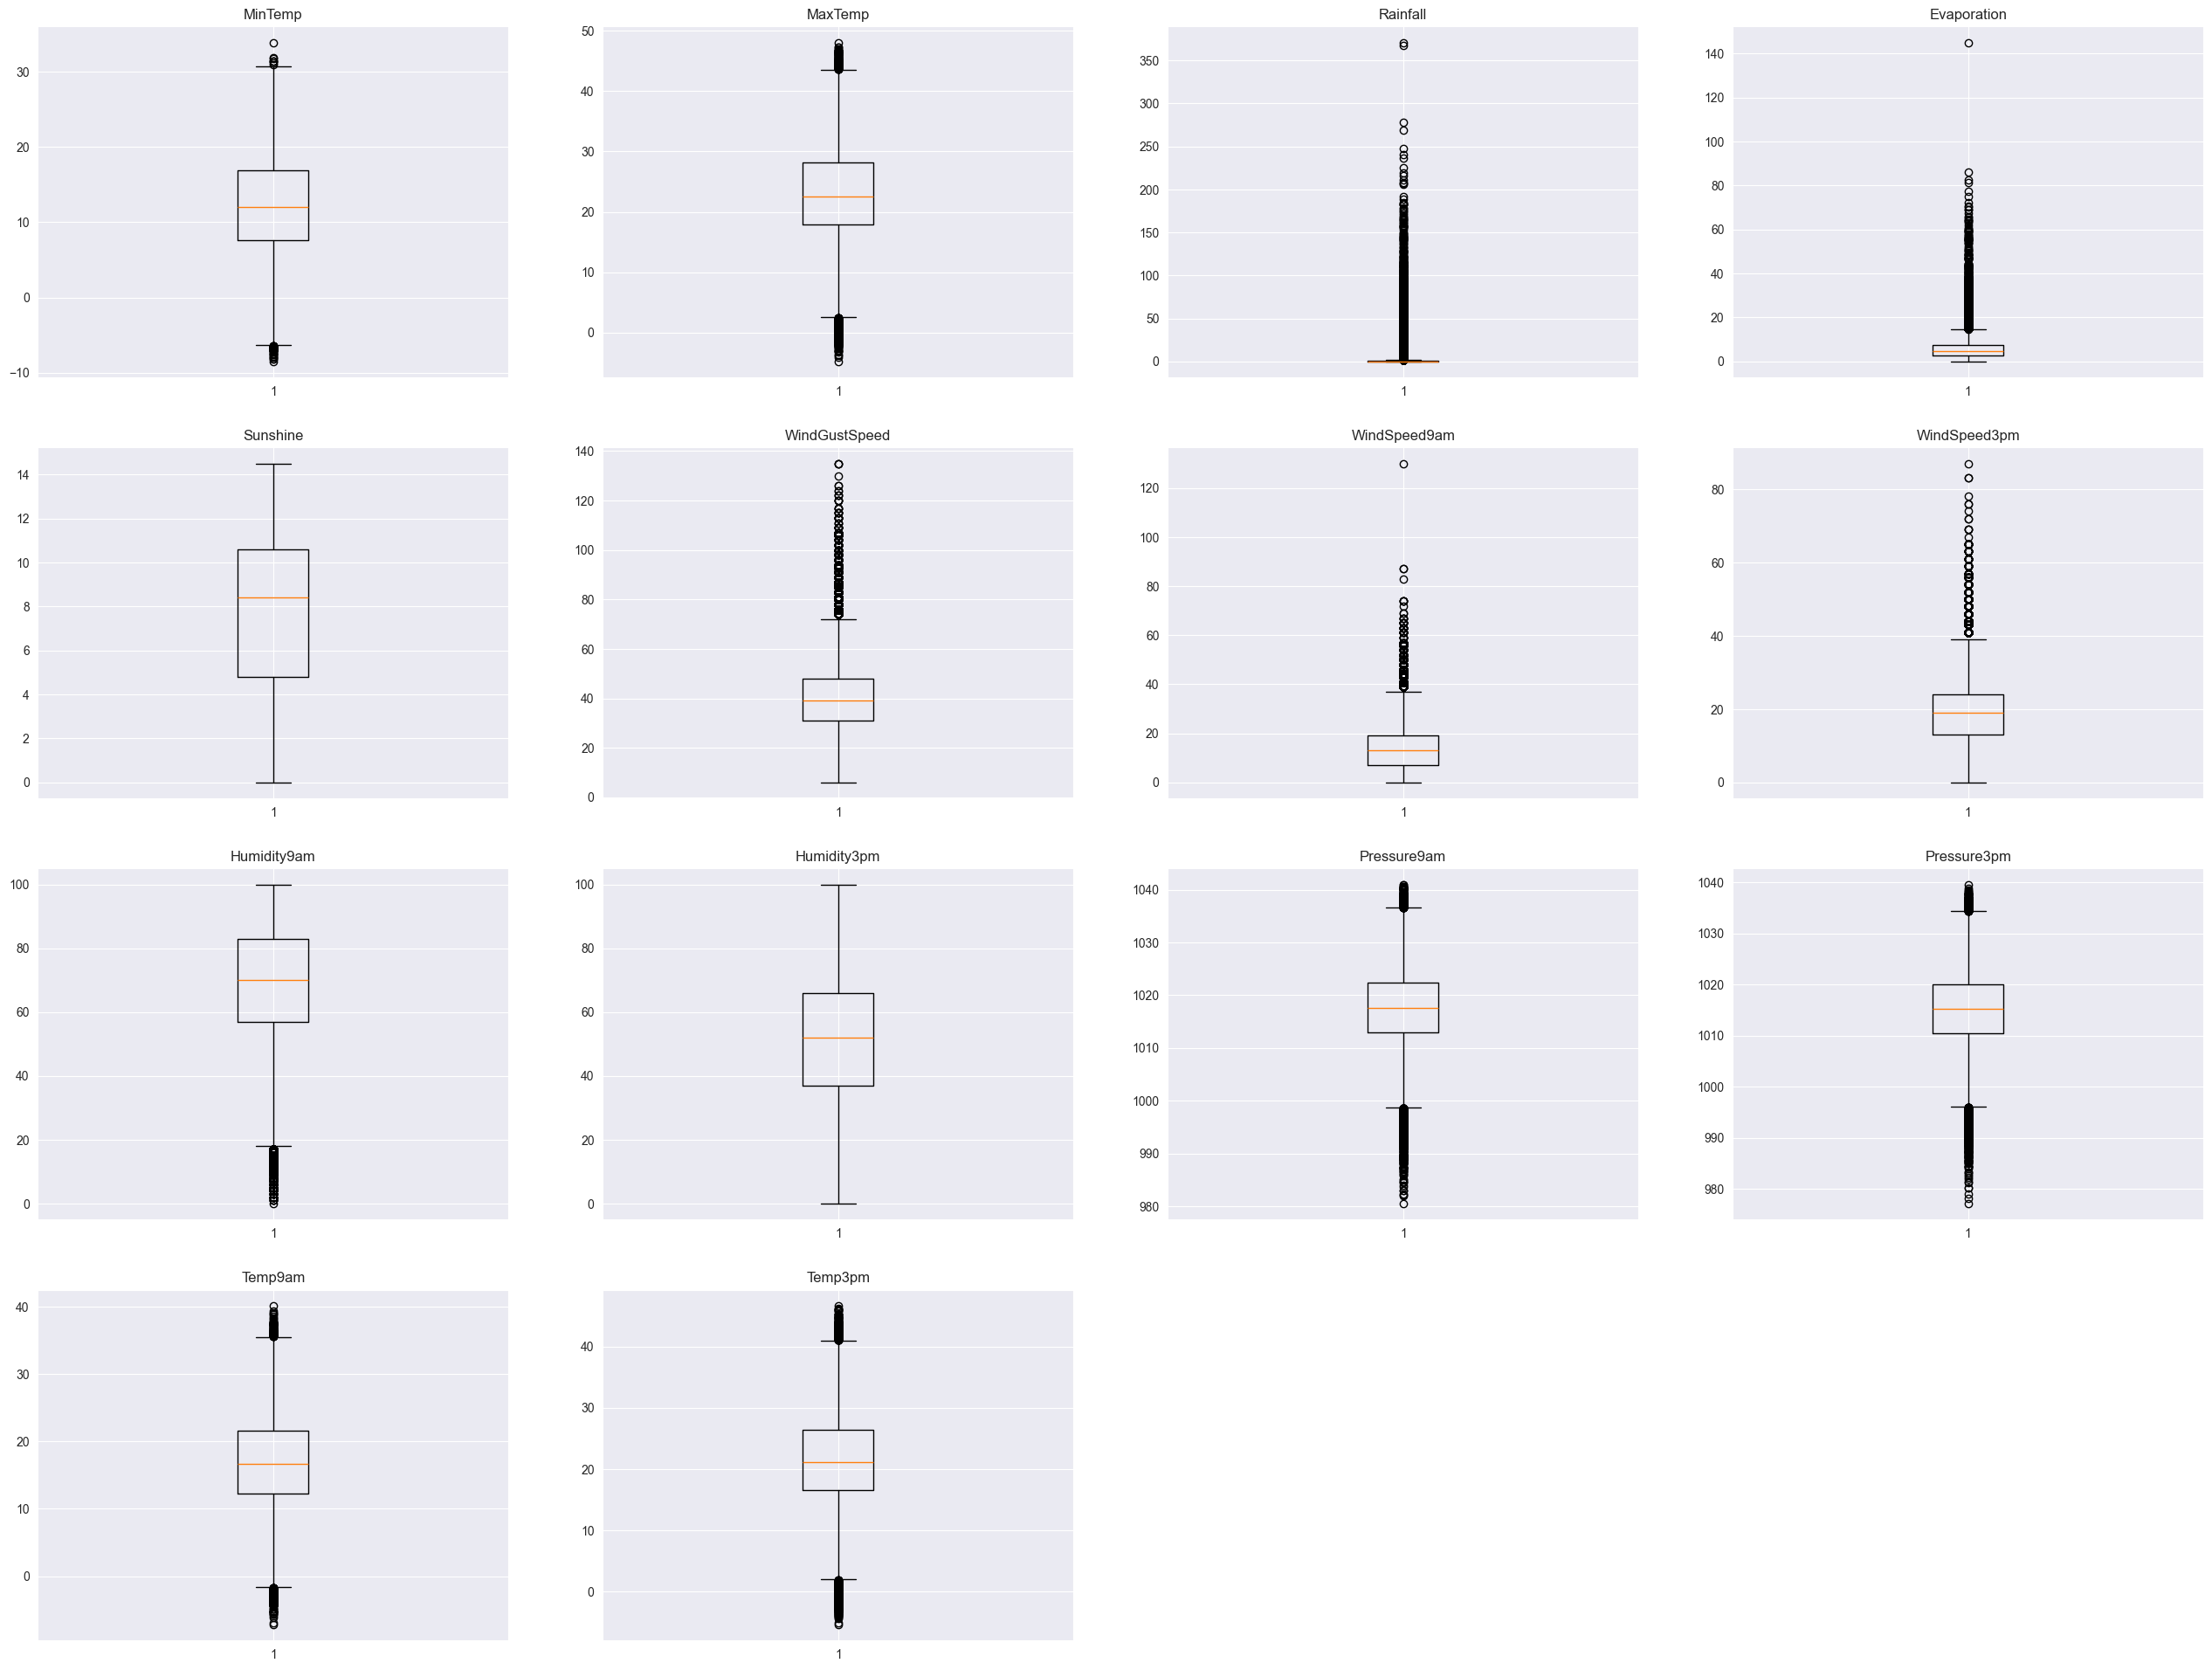

In [82]:
# Nils Becker (03817505)
# Prints a boxplot matrix 4 by 4
boxplot_matrix(df_eda, 4, 4)

### 3.2 Univariate Analysis

#### Target Variable
The target variable RainTomorrow exhibits a clear imbalance, with approximately 75.8% of observations labeled as No rain and 21.9% as Rain (2.25% of values are missing). This distribution reflects typical meteorological conditions, where there are substantially more non-rainy days than rainy days. We therefore assume a realistic measurement process and rather little amount of artifacts. The relatively small proportion of missing values suggests that the target variable is largely complete. However, these observations should be handled during preprocessing.

Furthermore the above mentioned imbalance between the two categories has important implications for the modeling and accuracy evaluation. A model with such imbalance would already achieve a high accuracy (75,8 %), by just predicting No Rain for every single day. Consequently, evaluation should rely on imbalance-aware metrics such as F1-score. In addition, stratification should be applied when splitting the data into train and test sets. This is essential to obtain stable performance estimates and to avoid biased model evaluation.

=== Target report: RainTomorrow ===
Rows: 145460
Missing: 3267 (2.25%)

Counts:
RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64

Percentages:
RainTomorrow
No     75.84%
Yes    21.91%
NaN     2.25%
Name: count, dtype: object


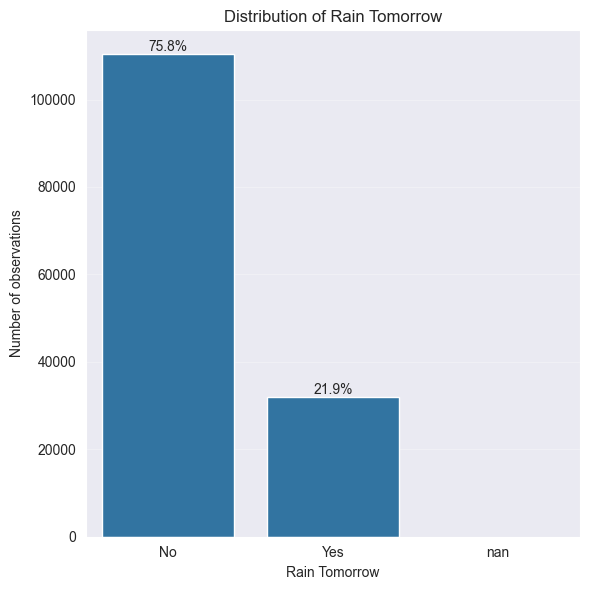

In [83]:
# Nils Becker (03817505)
# Calls the function for the target variable report
univariate_target_report(df_eda, target)

#### Feature Distribution Overview

The histogram matrix shows meteorologically plausible distribution patterns across all numerical features. In the following, all distrbutions are shortly described.

Temperature variables (MinTemp, Temp9am, Temp3pm, MaxTemp) are approximately symmetric and unimodal, resemble near-normal distributions with moderate spread. This indicates stable measurement behavior and gradual variability across seasons.

Rainfall is strongly right-skewed with a large mass near zero and a long tail of extreme values, confirming its episodic nature and explaining its high outlier share.

Evaporation shows a moderately right-skewed distribution with most observations at low values and occasional higher extremes.

Sunshine shows a bounded, asymmetric distribution with higher density toward larger values, reflecting the natural upper limit of daily sunshine hours. The shape suggests a smooth transition between cloudy and clear days rather than sharp extremes.

Wind-related variables (WindGustSpeed, WindSpeed9am, WindSpeed3pm) are right-skewed with long but thinning tails. Most observations cluster at lower to moderate wind speeds, while high-speed events occur infrequently but remain meaningful. Wind gusts speed shows the widest spread, consistent with their higher variability and outlier share. Wind speed observations in the morning (9am) tend to be lower, while wind speed observations in the afternoon (3pm) tend to be more moderate. This pattern indicates a systematic increase in wind speed throughout the day.

Humidity variables (Humidity9am, Humidity3pm) are bounded between 0 and 100 (%) and show moderately skewed distributions, with higher densities at mid-to-high humidity levels. The shape reflects diurnal differences and saturation effects, while the absence of heavy tails is consistent with their low outlier rates. The shift from rather high humidity values in the morning (9am), to rather moderate humidity values in the afternoon (3pm), indicates that a systematic decrease in humidity happens throughout the day.

Pressure variables (Pressure9am, Pressure3pm) exhibit very narrow, near-normal distributions centered around standard atmospheric pressure. The tight clustering and minimal tails indicate high measurement stability and explain the extremely low proportion of detected outliers. There is an almost imperceptible shift from higher to more moderate values between the pressure observations in the morning (9am) and the pressure readings in the afternoon (3pm).

Overall, the histogram matrix confirms that most variables are well-behaved and physically constrained, while rainfall and wind-related features exhibit naturally skewed distributions driven by episodic extreme events. This supports feature-specific preprocessing strategies rather than uniform transformations or outlier removal.

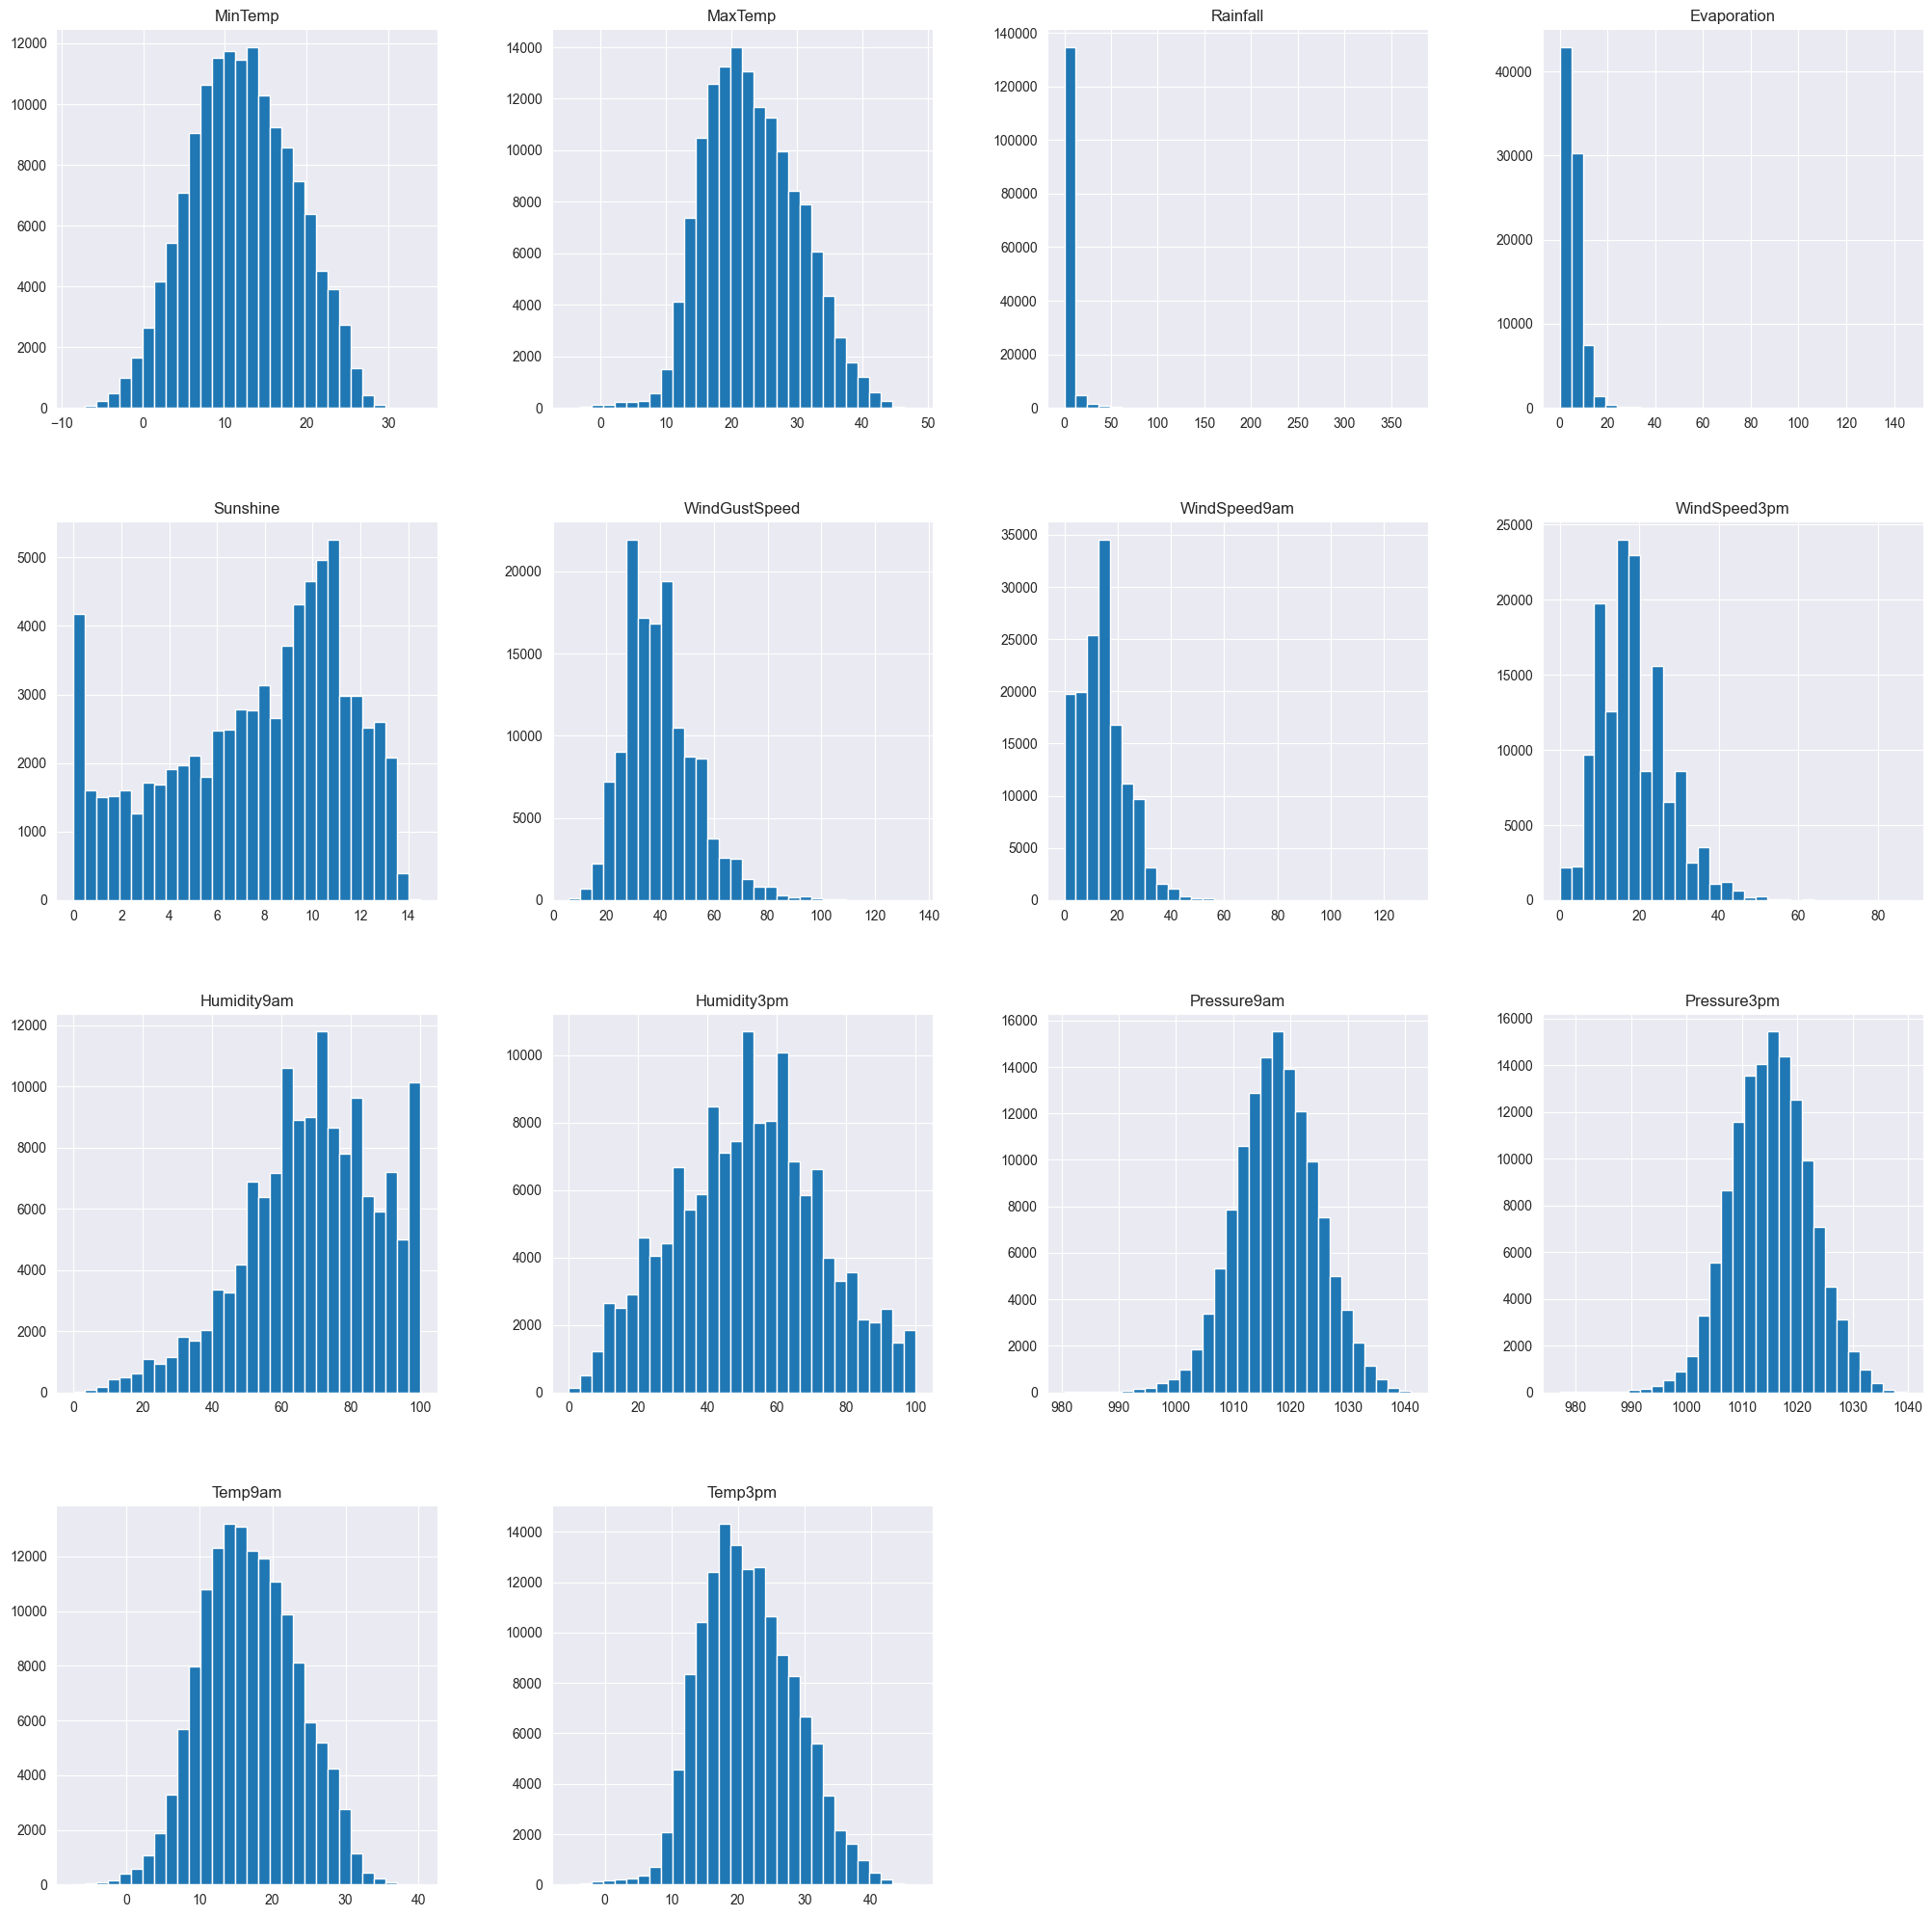

In [84]:
# Nils Becker (03817505)
df.hist(figsize=(25, 25),bins=30)
plt.show()

#### Categorical Variables Analysis
Categorical variable analysis aims to understand the distribution, prevalence, and data quality of non-numeric features within the dataset. By examining category frequencies, missing values, and class imbalances, this step provides insights into dominant patterns, potential biases, and limitations that may deliver implication for further analysis and model strategies.

##### Location
Location shows that weather stations are not evenly distributed across Australia. Observations are strongly concentrated along the coastal and urban regions, particularly in the east, southeast, southwest, and northern coastline, while large parts of the central and inland areas are sparsely covered or not represented.

This spatial pattern reflects population density and infrastructure availability rather than climatic conditions. As a result, the dataset exhibits a geographical sampling bias, which should be considered when interpreting spatial patterns and model results, especially for inland regions with limited sensor coverage.

=== Location (categorical) ===
Rows: 145460
Missing: 0 (0.0%)
Unique values: 49

Top 15 categories:
Location
Canberra        3436
Sydney          3344
Darwin          3193
Melbourne       3193
Brisbane        3193
Adelaide        3193
Perth           3193
Hobart          3193
Albany          3040
MountGambier    3040
Ballarat        3040
Townsville      3040
GoldCoast       3040
Cairns          3040
Launceston      3040
Name: count, dtype: Int64


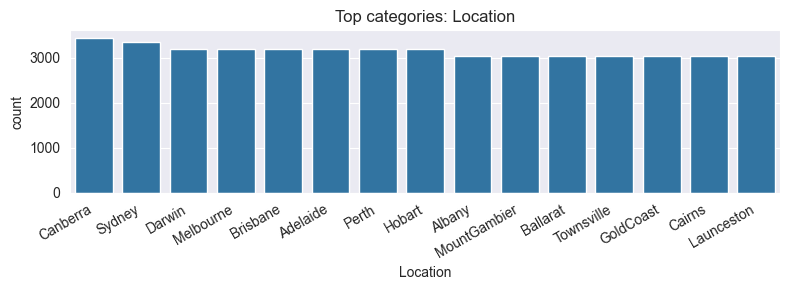

In [85]:
# Nils Becker (03817505)
univariate_report_categorical(df_eda,col='Location',top_k=15)

In [86]:
# Nils Becker (03817505)
# If the geocodes are not loaded properly before, fall back on the local CSV file.
if df_geocodes.empty:
    df_geocodes = pd.read_csv('df_geocodes.csv')

In [87]:
# Nils Becker (03817505)
# Drops NaN values for visualization.
df_geocodes = df_geocodes.dropna(subset=["Latitude", "Longitude"]).copy()


# Creates a map with the locations.
map_locations_australia = folium.Map(location=[-25.2744, 133.7751], zoom_start=5)

# Add locations as circle markers.
for _, row in df_geocodes.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        tooltip=row['Location'], # Shows location name on hover
        popup=(
            f"<strong>{row['Location']}</strong><br>"
            f"Rainfall: {row['Rainfall']:.2f}"
        ),
        icon=folium.Icon(color = 'red', icon="map-marker", prefix="fa")
    ).add_to(map_locations_australia)

# Saves the map as HTML file for the presentation.
map_locations_australia.save('locations.html')

# Shows the map.
map_locations_australia

##### Wind Gust Direction
WindGustDir are not evenly distributed across directions but are instead concentrated in specific sectors. Westerly and southerly directions occur most frequently, while easterly and north-easterly directions are comparatively less common. Overall, the univariate analysis indicates that wind gust directions exhibit a clear directional structure.

=== WindGustDir (categorical) ===
Rows: 145460
Missing: 10326 (7.1%)
Unique values: 17

Top 17 categories:
WindGustDir
<NA>    10326
W        9915
SE       9418
N        9313
SSE      9216
E        9181
S        9168
WSW      9069
SW       8967
SSW      8736
WNW      8252
NW       8122
ENE      8104
ESE      7372
NE       7133
NNW      6620
NNE      6548
Name: count, dtype: Int64


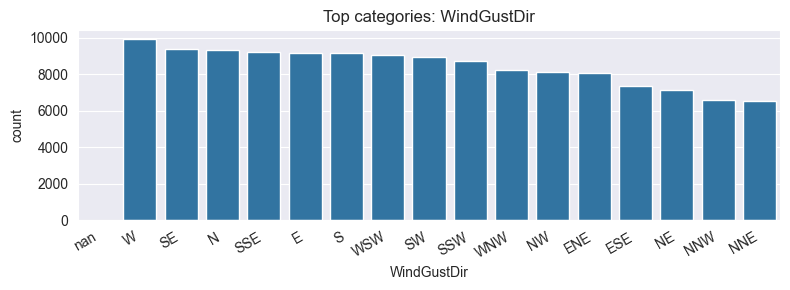

In [88]:
# Nils Becker (03817505)
univariate_report_categorical(df_eda,col='WindGustDir',top_k=17)

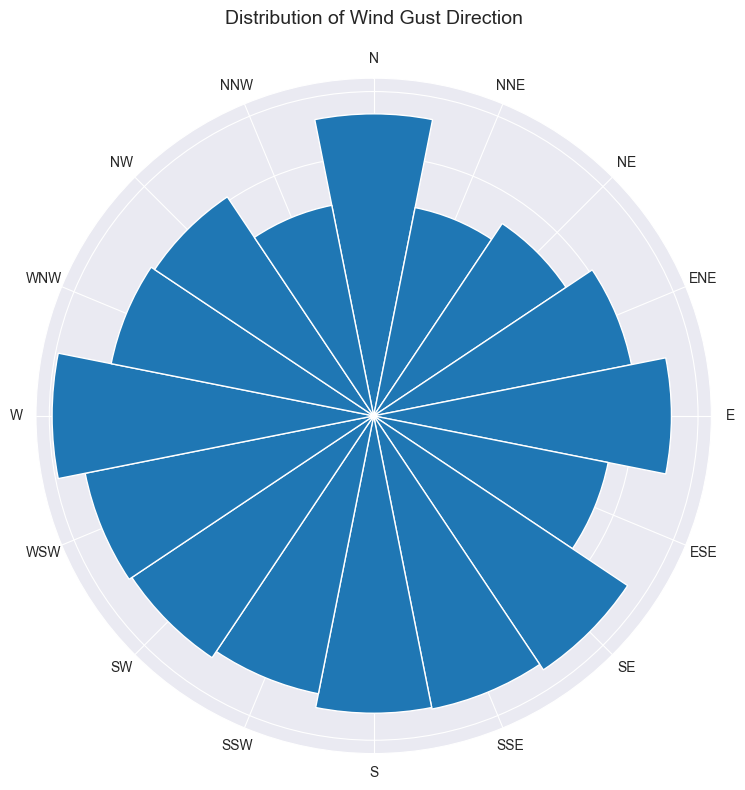

In [89]:
# Define compass order for wind directions
WindGustDir_order = [
    'N', 'NNE', 'NE', 'ENE',
    'E', 'ESE', 'SE', 'SSE',
    'S', 'SSW', 'SW', 'WSW',
    'W', 'WNW', 'NW', 'NNW'
]

# Count occurrences of each wind gust direction
dir_counts = (
    df_eda["WindGustDir"]
    .value_counts()
    .reindex(WindGustDir_order)
    .fillna(0)
)

# Prepare polar coordinates
n_dirs = len(WindGustDir_order)
angles = np.linspace(0, 2 * np.pi, n_dirs, endpoint=False)
heights = dir_counts.values
width = 2 * np.pi / n_dirs

# Create polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

ax.bar(angles, heights, width=width, align="center")

# Compass-style orientation
ax.set_theta_zero_location("N")   # North at the top
ax.set_theta_direction(-1)        # Clockwise rotation

ax.set_xticks(angles)
ax.set_xticklabels(WindGustDir_order)
ax.set_yticklabels([])

ax.set_title(
    "Distribution of Wind Gust Direction",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

##### Wind Direction 9am
WindDir9am shows a clear directional structure rather than a uniform pattern. Winds are most frequently observed from the northern sector. Subsequently eastern, and southern sectors are most frequently observed, while north-easterly and west-south-westerly directions occur less often. Overall, the univariate analysis indicates that morning wind directions follow stable prevailing patterns, likely driven by meterological reasons rather than random variation.

=== WindDir9am (categorical) ===
Rows: 145460
Missing: 10566 (7.3%)
Unique values: 17

Top 17 categories:
WindDir9am
N       11758
<NA>    10566
SE       9287
E        9176
SSE      9112
NW       8749
S        8659
W        8459
SW       8423
NNE      8129
NNW      7980
ENE      7836
NE       7671
ESE      7630
SSW      7587
WNW      7414
WSW      7024
Name: count, dtype: Int64


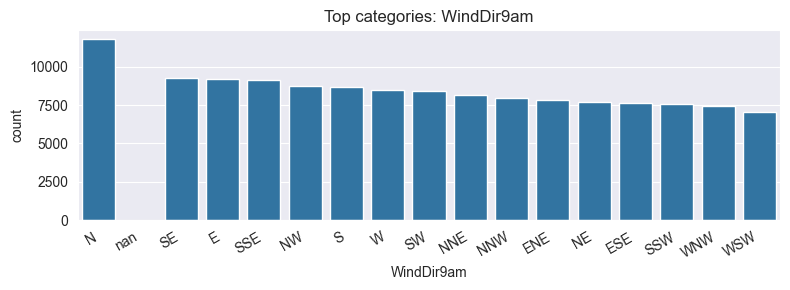

In [90]:
# Nils Becker (03817505)
univariate_report_categorical(df_eda,col='WindDir9am',top_k=17)

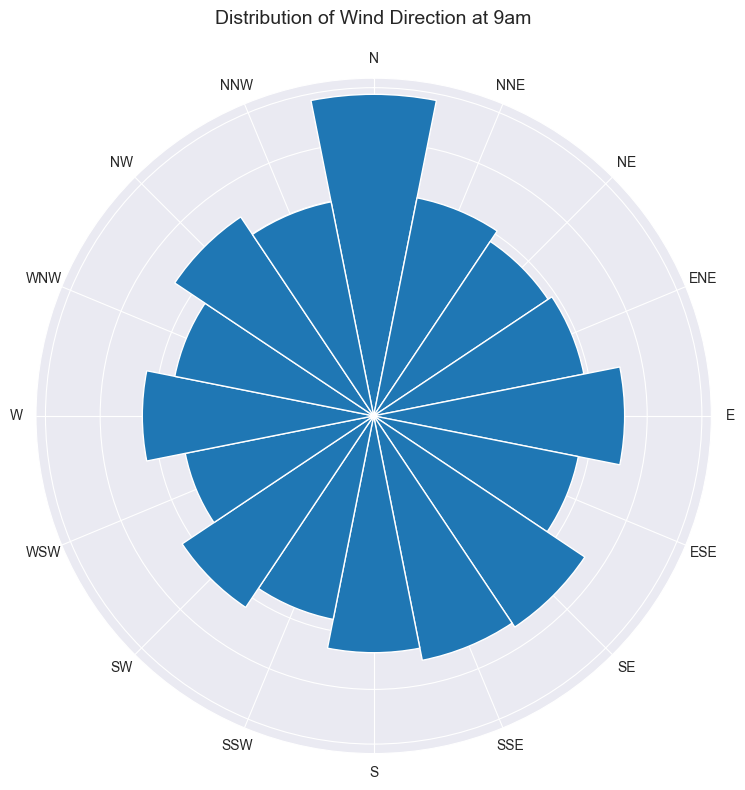

In [91]:
# Define compass order for wind directions
WindDir9am_order = [
    'N', 'NNE', 'NE', 'ENE',
    'E', 'ESE', 'SE', 'SSE',
    'S', 'SSW', 'SW', 'WSW',
    'W', 'WNW', 'NW', 'NNW'
]

# Count occurrences of each wind gust direction
dir_counts = (
    df_eda["WindDir9am"]
    .value_counts()
    .reindex(WindDir9am_order)
    .fillna(0)
)

# Prepare polar coordinates
n_dirs = len(WindDir9am_order)
angles = np.linspace(0, 2 * np.pi, n_dirs, endpoint=False)
heights = dir_counts.values
width = 2 * np.pi / n_dirs

# Create polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

ax.bar(angles, heights, width=width, align="center")

# Compass-style orientation
ax.set_theta_zero_location("N")   # North at the top
ax.set_theta_direction(-1)        # Clockwise rotation

ax.set_xticks(angles)
ax.set_xticklabels(WindDir9am_order)
ax.set_yticklabels([])

ax.set_title(
    "Distribution of Wind Direction at 9am",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

##### Wind Direction 3pm
WindDir3pm shows a stronger concentration in the southern, south-eastern, and western sectors. Compared to the morning distribution, wind directions in the afternoon appear more focused and intensified, with a noticeable shift toward southerly and westerly flows. Furthermore, the 9am wind directions are more evenly spread across directions. This comparison suggests a systematic diurnal shift in wind patterns, where winds tend to rotate and strengthen toward southern and western directions as the day progresses, likely driven by daytime heating and atmospheric mixing.

=== WindDir3pm (categorical) ===
Rows: 145460
Missing: 4228 (2.9%)
Unique values: 17

Top 17 categories:
WindDir3pm
SE      10838
W       10110
S        9926
WSW      9518
SSE      9399
SW       9354
N        8890
WNW      8874
NW       8610
ESE      8505
E        8472
NE       8263
SSW      8156
NNW      7870
ENE      7857
NNE      6590
<NA>     4228
Name: count, dtype: Int64


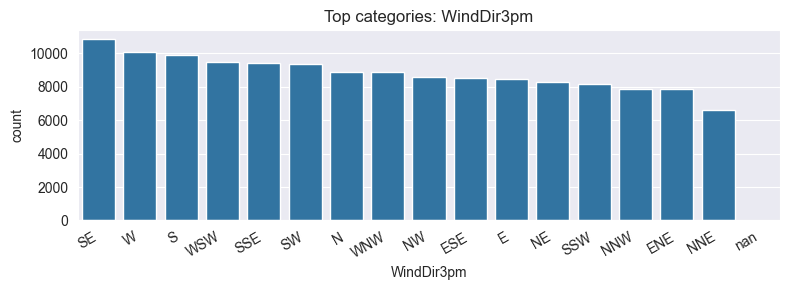

In [92]:
# Nils Becker (03817505)
univariate_report_categorical(df_eda,col='WindDir3pm',top_k=17)

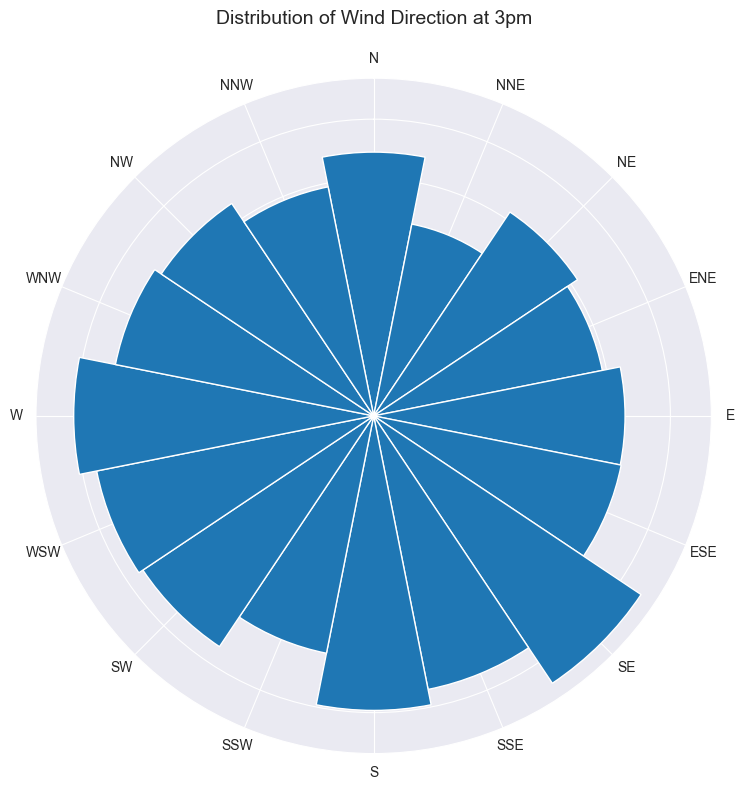

In [93]:
# Define compass order for wind directions
WindDir3pm_order = [
    'N', 'NNE', 'NE', 'ENE',
    'E', 'ESE', 'SE', 'SSE',
    'S', 'SSW', 'SW', 'WSW',
    'W', 'WNW', 'NW', 'NNW'
]

# Count occurrences of each wind gust direction
dir_counts = (
    df_eda["WindDir3pm"]
    .value_counts()
    .reindex(WindDir3pm_order)
    .fillna(0)
)

# Prepare polar coordinates
n_dirs = len(WindDir3pm_order)
angles = np.linspace(0, 2 * np.pi, n_dirs, endpoint=False)
heights = dir_counts.values
width = 2 * np.pi / n_dirs

# Create polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

ax.bar(angles, heights, width=width, align="center")

# Compass-style orientation
ax.set_theta_zero_location("N")   # North at the top
ax.set_theta_direction(-1)        # Clockwise rotation

ax.set_xticks(angles)
ax.set_xticklabels(WindDir3pm_order)
ax.set_yticklabels([])

ax.set_title(
    "Distribution of Wind Direction at 3pm",
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

##### Rain Today
RainToday shows a clear class imbalance, with the majority of observations labeled as No rain (approximately three quarters of the data), while Rain occurs substantially less frequently. A small proportion of values is missing (around 2%), indicating that the variable is largely complete. This distribution reflects typical weather patterns, where dry days are more common than rainy ones.

=== RainToday (categorical) ===
Rows: 145460
Missing: 3261 (2.2%)
Unique values: 3

Top 10 categories:
RainToday
No      110319
Yes      31880
<NA>      3261
Name: count, dtype: Int64


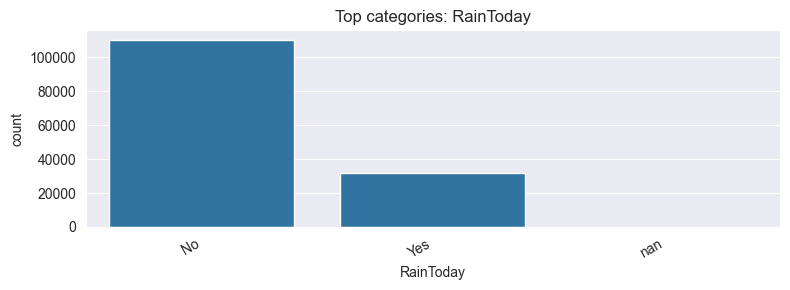

In [94]:
# Nils Becker (03817505)
univariate_report_categorical(df_eda,col='RainToday')

##### Cloud 9am
Cloud9am shows a substantial proportion of missing values, indicating that early-morning cloud cover measurements are not consistently available across all observations. Among the recorded values, higher cloud cover levels (notably categories around 7–8 oktas) occur more frequently than very low values, suggesting that mornings are often partially to heavily overcast rather than completely clear. Overall, the distribution reflects both data availability limitations and a tendency toward moderate to high cloudiness in the morning hours.

=== Cloud9am (categorical) ===
Rows: 145460
Missing: 55888 (38.4%)
Unique values: 11

Top 10 categories:
Cloud9am
<NA>    55888
7.0     19972
1.0     15687
8.0     14697
0.0      8642
6.0      8171
2.0      6500
3.0      5914
5.0      5567
4.0      4420
Name: count, dtype: Int64


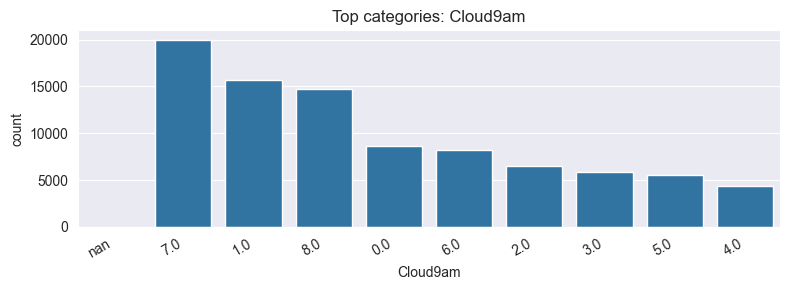

In [95]:
# Nils Becker (03817505)
univariate_report_categorical(df_eda,col='Cloud9am')

#### Numerical Variables Analysis
Numerical variable analysis focuses on examining the distribution, range, and variability of continuous features in the dataset. By assessing central tendencies, missingness, skewness, and the presence of outliers, this step helps identify underlying data structures, detect anomalies, and delivers implications for further analysis and model strategies.

##### MinTemp
MinTemp shows that the variable is almost fully complete, with nearly no missing values. The distribution is approximately symmetric and bell-shaped, indicating a well-behaved temperature pattern. The boxplot confirms a low presence of extreme values, with no outliers detected under the IQR rule, suggesting high data quality and suitability for direct use in modeling.

=== MinTemp (numeric) ===
Rows: 145460
Missing: 1485 (1.0%)

Descriptive statistics:
count    143975.000000
mean         12.194034
std           6.398495
min          -8.500000
25%           7.600000
50%          12.000000
75%          16.900000
max          33.900000
Name: MinTemp, dtype: float64

Skewness: 0.02


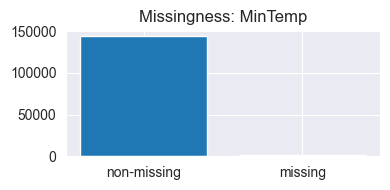

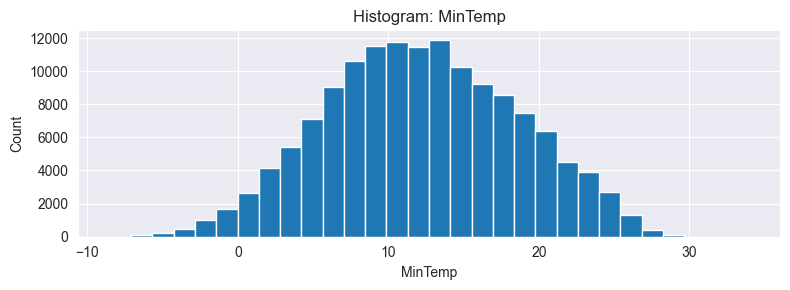

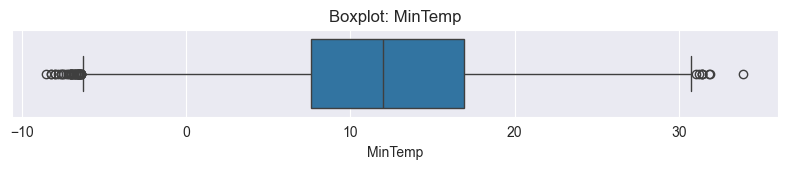

Outliers (IQR rule): 0.0%


In [96]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda,col='MinTemp')

##### Maximum Temperature
MaxTemp shows that the variable is almost fully complete, with nearly no missing values. The distribution is approximately symmetric and bell-shaped, indicating a well-behaved temperature pattern. The boxplot confirms a low presence of extreme values, with almost no outliers detected under the IQR rule, suggesting high data quality and suitability for direct use in modeling.

=== MaxTemp (numeric) ===
Rows: 145460
Missing: 1261 (0.9%)

Descriptive statistics:
count    144199.000000
mean         23.221348
std           7.119049
min          -4.800000
25%          17.900000
50%          22.600000
75%          28.200000
max          48.100000
Name: MaxTemp, dtype: float64

Skewness: 0.22


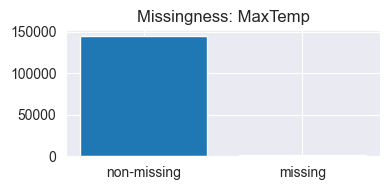

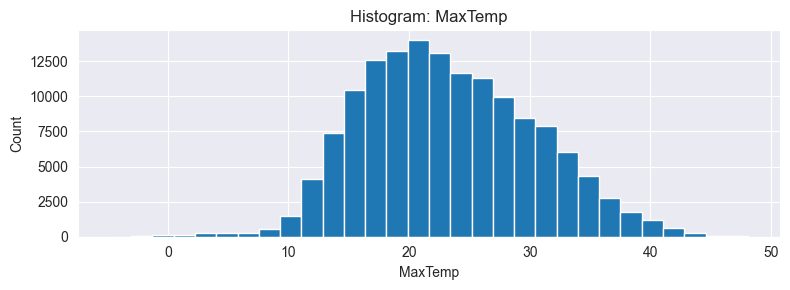

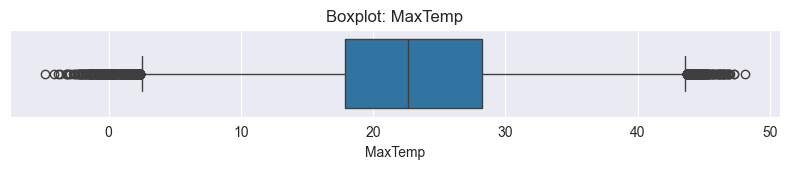

Outliers (IQR rule): 0.3%


In [97]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda,col='MaxTemp')

##### Rainfall
Rainfall shows a highly right-skewed distribution, with most observations concentrated at very low or zero values and a small number of extreme rainfall events extending far into the upper range. This is reflected in the high skewness and the large maximum value. While missing values are negligible, a substantial proportion of observations (about 18%) are classified as outliers under the IQR rule, indicating that extreme rainfall events are a structural characteristic of the variable. Consequently, rainfall requires special handling in modeling, such as transformation or separate treatment of zero and extreme values.

=== Rainfall (numeric) ===
Rows: 145460
Missing: 3261 (2.2%)

Descriptive statistics:
count    142199.000000
mean          2.360918
std           8.478060
min           0.000000
25%           0.000000
50%           0.000000
75%           0.800000
max         371.000000
Name: Rainfall, dtype: float64

Skewness: 9.84


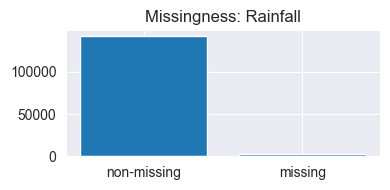

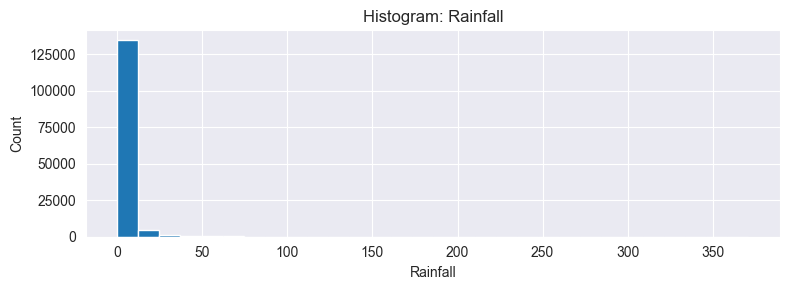

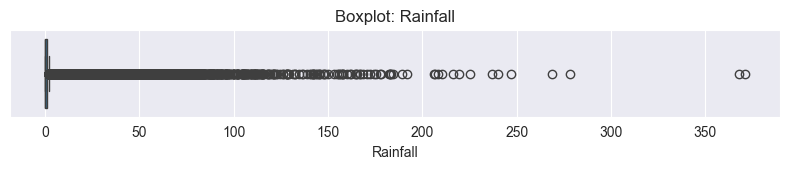

Outliers (IQR rule): 17.6%


In [93]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda,col='Rainfall')

=== Rainfall (numeric) ===
Rows: 116621
Missing: 0 (0.0%)

Descriptive statistics:
count    116621.000000
mean          0.155433
std           0.392923
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           2.000000
Name: Rainfall, dtype: float64

Skewness: 2.99


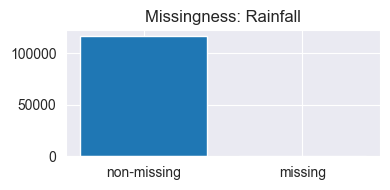

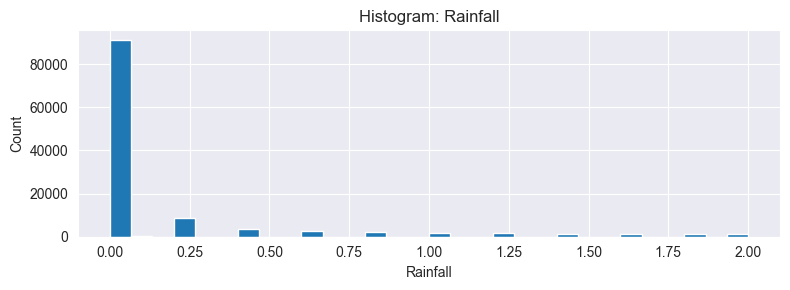

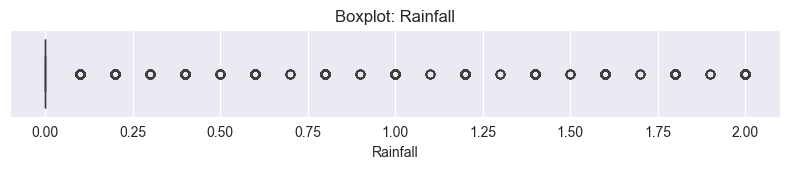

IQR is zero → outlier detection not meaningful.


In [95]:
# Nils Becker (03817505)
# Since the outlier share of Rainfall exceeds the 2% threshold, defined in EDA's introduction, we use IQR-based capping for better visualization.
# To improve the interpretability of the distribution, extreme rainfall values are identified using the one-sided IQR 1.5 method. Observation above this threshold are therefore excluded.
q1 = df["Rainfall"].quantile(0.25)
q3 = df["Rainfall"].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr

univariate_report_numerical(df_eda[df_eda['Rainfall'] <= upper], col='Rainfall')

##### Evaporation
Evaporation reveals a right-skewed distribution, with most observations concentrated at low to moderate values and a long tail of higher evaporation levels. This is reflected in the positive skewness and the presence of several extreme values visible in the boxplot. A noticeable proportion of values is missing, indicating incomplete measurement coverage. While most evaporation values lie within a plausible range, the heavy tail suggests that extreme evaporation events are a recurring but infrequent phenomenon and should be treated carefully in modeling.

=== Evaporation (numeric) ===
Rows: 145460
Missing: 62790 (43.2%)

Descriptive statistics:
count    82670.000000
mean         5.468232
std          4.193704
min          0.000000
25%          2.600000
50%          4.800000
75%          7.400000
max        145.000000
Name: Evaporation, dtype: float64

Skewness: 3.76


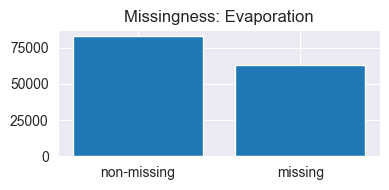

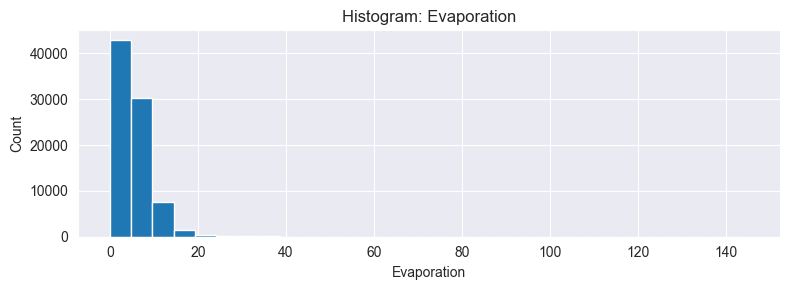

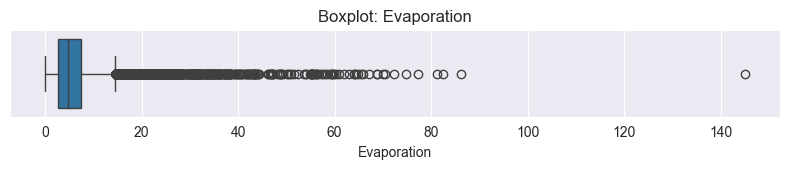

Outliers (IQR rule): 1.4%


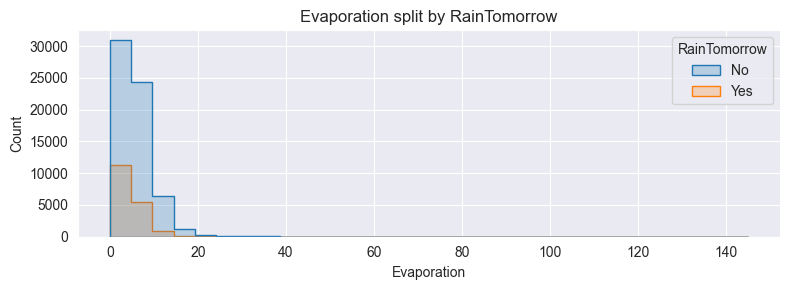

In [96]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda, col='Evaporation', target='RainTomorrow')

##### Sunshine
Sunshine shows a largely well-behaved distribution, with values concentrated between moderate to high sunshine hours. The histogram indicates a slight left skew, suggesting that days with higher sunshine duration are more common than very low-sunshine days. Although a noticeable share of observations is missing, the recorded values exhibit no outliers under the IQR rule. Overall, sunshine appears to be a reliable numerical variable with a clear central tendency and limited extreme behavior.

=== Sunshine (numeric) ===
Rows: 145460
Missing: 69835 (48.0%)

Descriptive statistics:
count    75625.000000
mean         7.611178
std          3.785483
min          0.000000
25%          4.800000
50%          8.400000
75%         10.600000
max         14.500000
Name: Sunshine, dtype: float64

Skewness: -0.50


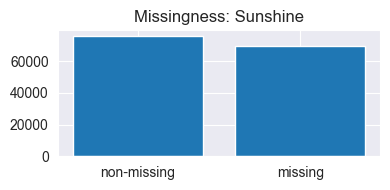

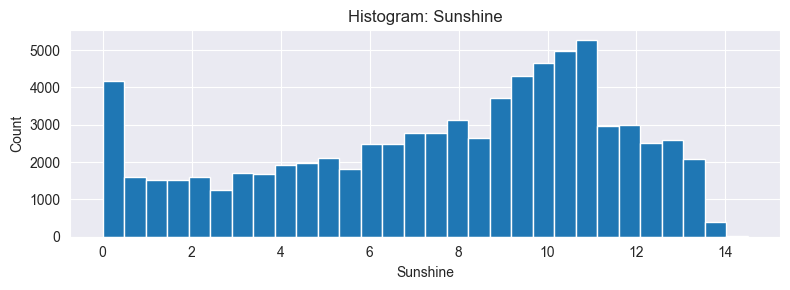

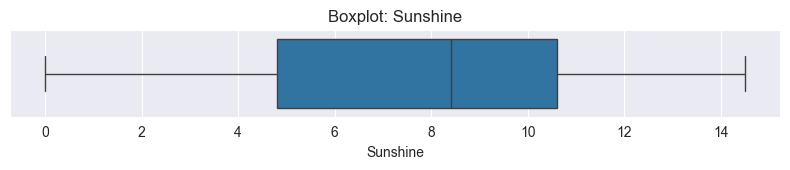

Outliers (IQR rule): 0.0%


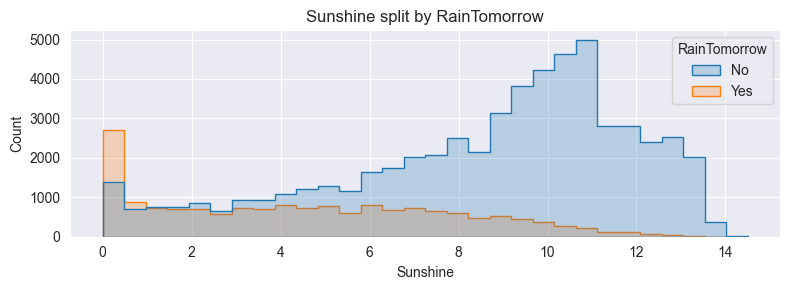

In [97]:
univariate_report_numerical(df_eda, col='Sunshine', target='RainTomorrow')

##### Wind Gust Speed
WindGustSpeed shows a right-skewed distribution, with most observations concentrated at moderate wind gust speeds and a long tail toward higher values. Extreme gust events are present but relatively infrequent, as reflected by an outlier share of about 2% under the IQR rule. Therefore, we use IQR-based capping in a second visualization. Missing values are limited, indicating good data coverage. Overall, wind gust speed exhibits natural variability with occasional extremes that are meteorologically plausible and should be handled with robust modeling approaches rather than removed.

=== WindGustSpeed (numeric) ===
Rows: 145460
Missing: 10263 (7.1%)

Descriptive statistics:
count    135197.000000
mean         40.035230
std          13.607062
min           6.000000
25%          31.000000
50%          39.000000
75%          48.000000
max         135.000000
Name: WindGustSpeed, dtype: float64

Skewness: 0.87


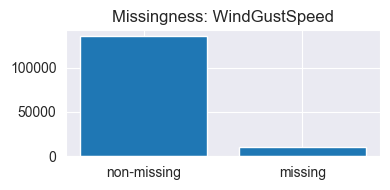

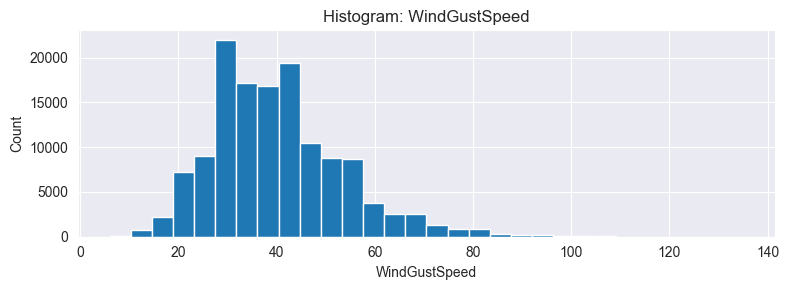

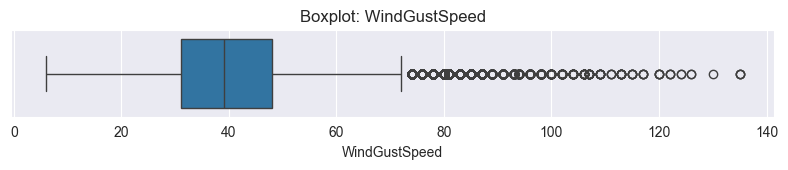

Outliers (IQR rule): 2.1%


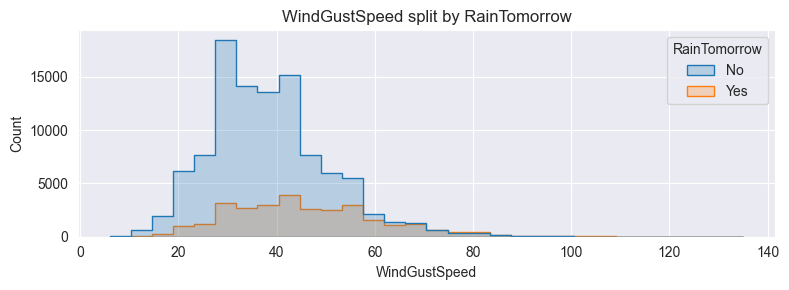

In [98]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda, col='WindGustSpeed', target='RainTomorrow')

=== WindGustSpeed (numeric) ===
Rows: 132105
Missing: 0 (0.0%)

Descriptive statistics:
count    132105.000000
mean         39.049907
std          12.055309
min           6.000000
25%          31.000000
50%          37.000000
75%          46.000000
max          72.000000
Name: WindGustSpeed, dtype: float64

Skewness: 0.40


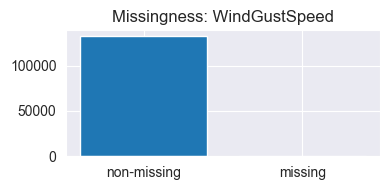

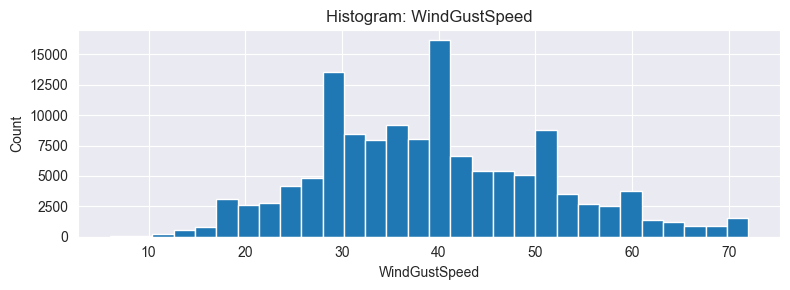

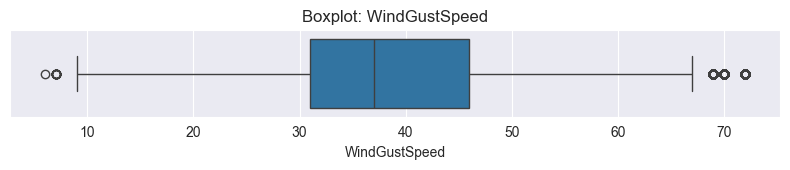

Outliers (IQR rule): 1.8%


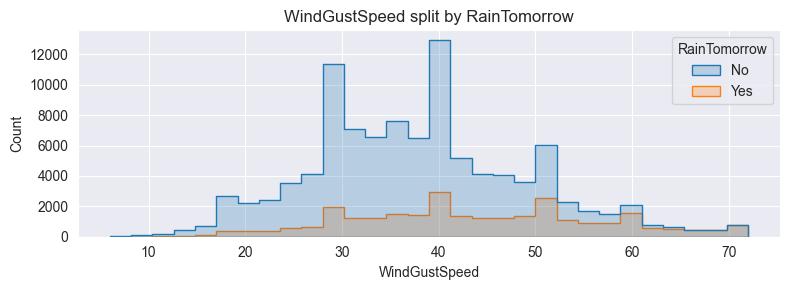

In [100]:
# Nils Becker (03817505)
# Since the outlier share of Rainfall exceeds the 2% threshold, defined in EDA's introduction, we use IQR-based capping for better visualization.
# To improve the interpretability of the distribution, extreme wind gust speed values are identified using the one-sided IQR 1.5 method. Observation above this threshold are therefore excluded.
q1 = df['WindGustSpeed'].quantile(0.25)
q3 = df['WindGustSpeed'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr

univariate_report_numerical(df_eda[df_eda['WindGustSpeed'] <= upper], col='WindGustSpeed', target='RainTomorrow')

##### Wind Speed at 9am
WindSpeed9am shows a moderately right-skewed distribution, with most observations concentrated at low to moderate wind speeds typical of morning conditions. Missing values are minimal, indicating good data completeness. A small proportion of higher wind speeds is classified as outliers (about 1% under the IQR rule), reflecting occasional stronger morning winds. Overall, wind speed at 9 am appears stable with limited extremes and a clear central tendency.

=== WindSpeed9am (numeric) ===
Rows: 145460
Missing: 1767 (1.2%)

Descriptive statistics:
count    143693.000000
mean         14.043426
std           8.915375
min           0.000000
25%           7.000000
50%          13.000000
75%          19.000000
max         130.000000
Name: WindSpeed9am, dtype: float64

Skewness: 0.78


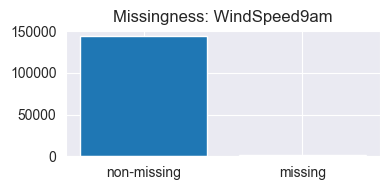

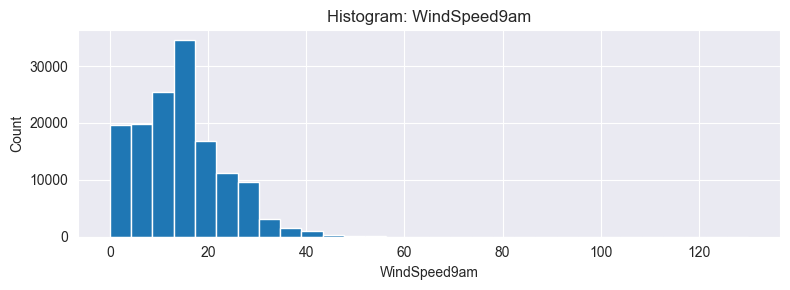

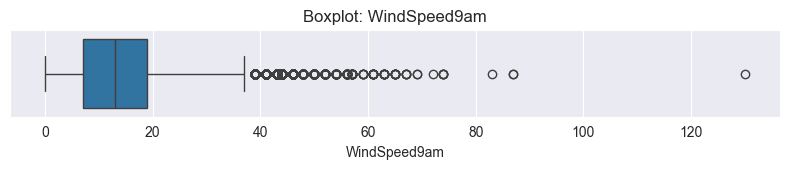

Outliers (IQR rule): 1.2%


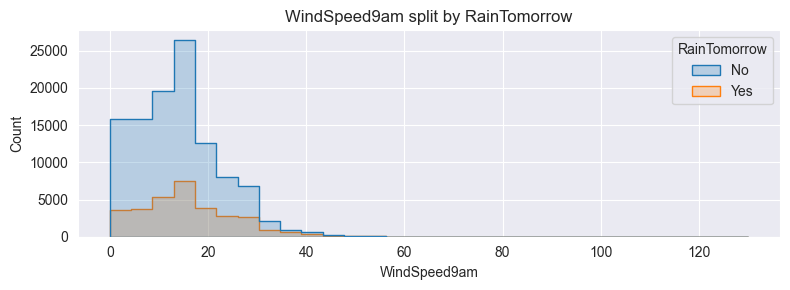

In [101]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda, col='WindSpeed9am', target='RainTomorrow')

##### Wind Speed at 3pm
WindSpeed3pm shows a moderately right-skewed distribution, with most observations concentrated at higher wind speeds than in the morning, reflecting typical daytime wind intensification. Missing values are negligible, indicating good data completeness. A small share of observations (below 2%) is classified as outliers under the IQR rule, corresponding to occasional strong afternoon winds. Overall, wind speed at 3 pm is more variable than at 9 am but remains well-behaved and meteorologically plausible.

=== WindSpeed3pm (numeric) ===
Rows: 145460
Missing: 3062 (2.1%)

Descriptive statistics:
count    142398.000000
mean         18.662657
std           8.809800
min           0.000000
25%          13.000000
50%          19.000000
75%          24.000000
max          87.000000
Name: WindSpeed3pm, dtype: float64

Skewness: 0.63


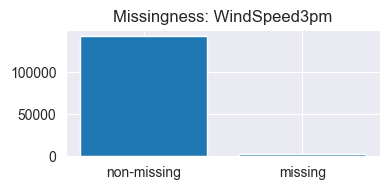

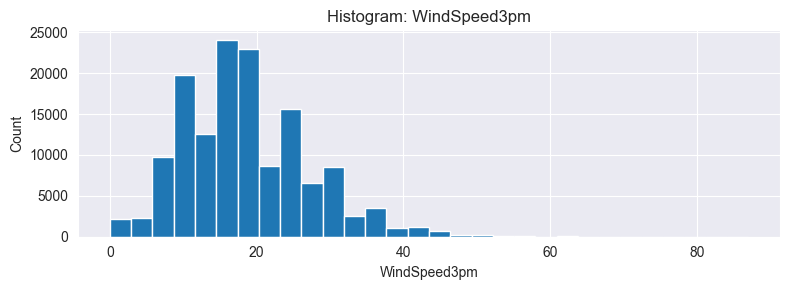

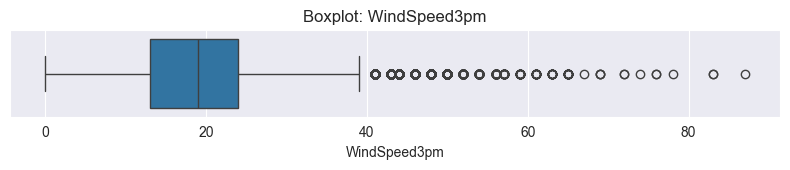

Outliers (IQR rule): 1.7%


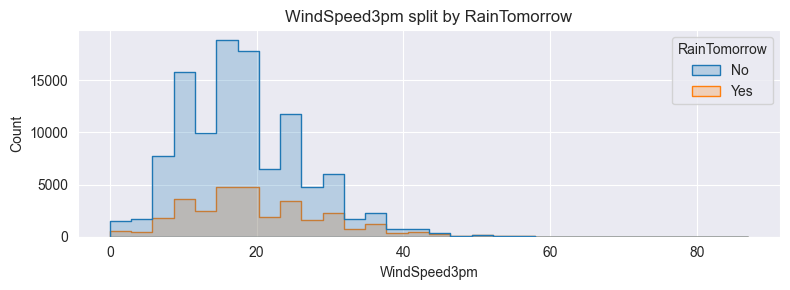

In [102]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda, col='WindSpeed3pm', target='RainTomorrow')

##### Humidity 9am
Humidity9am shows a slightly left-skewed distribution, with most observations concentrated at moderate to high humidity levels typical of morning conditions. Missing values are minimal, indicating good data completeness. A small proportion of values (around 1%) is classified as outliers under the IQR rule, primarily at very low humidity levels. Overall, morning humidity appears stable, bounded, and suitable for direct use in further analysis.

=== Humidity9am (numeric) ===
Rows: 145460
Missing: 2654 (1.8%)

Descriptive statistics:
count    142806.000000
mean         68.880831
std          19.029164
min           0.000000
25%          57.000000
50%          70.000000
75%          83.000000
max         100.000000
Name: Humidity9am, dtype: float64

Skewness: -0.48


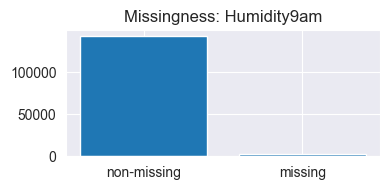

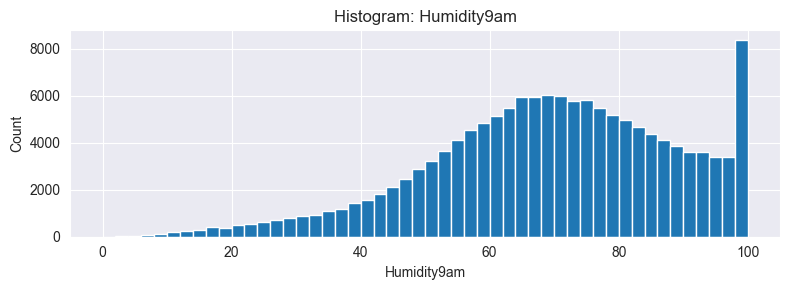

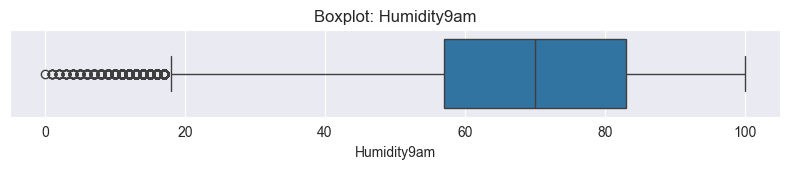

Outliers (IQR rule): 1.0%


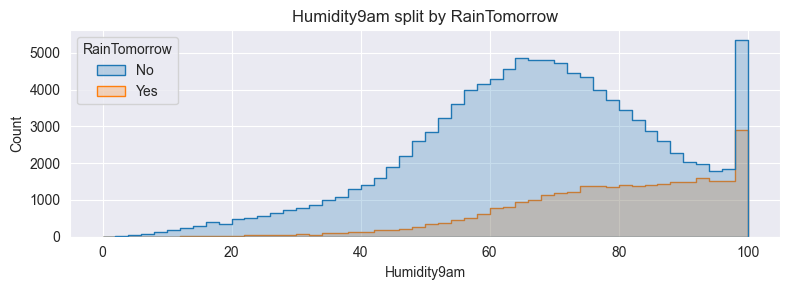

In [103]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda, col='Humidity9am', target='RainTomorrow', bins = 50)

##### Humidity 3pm
Humidity3pm shows a slightly left-skewed distribution, with most observations concentrated at moderate humidity levels typical of afternoon conditions. Missing values are minimal, indicating good data completeness. A small share of observations (around 1%) is classified as outliers under the IQR rule, mainly at very low humidity values. Overall, afternoon humidity appears stable, bounded, and suitable for direct use in further analysis.

=== Humidity9am (numeric) ===
Rows: 145460
Missing: 2654 (1.8%)

Descriptive statistics:
count    142806.000000
mean         68.880831
std          19.029164
min           0.000000
25%          57.000000
50%          70.000000
75%          83.000000
max         100.000000
Name: Humidity9am, dtype: float64

Skewness: -0.48


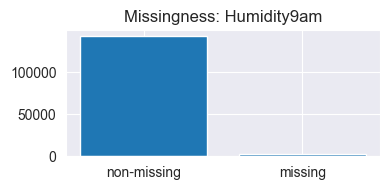

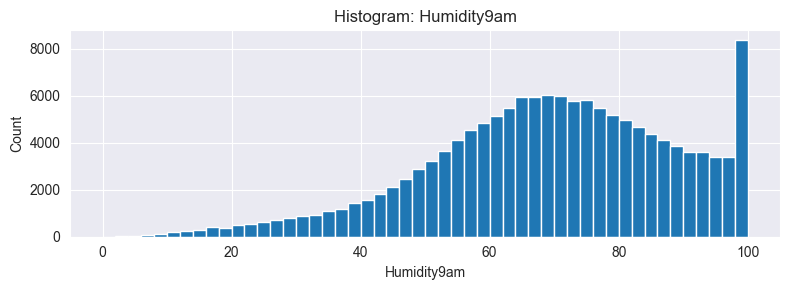

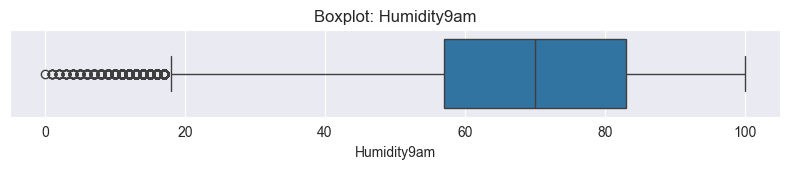

Outliers (IQR rule): 1.0%


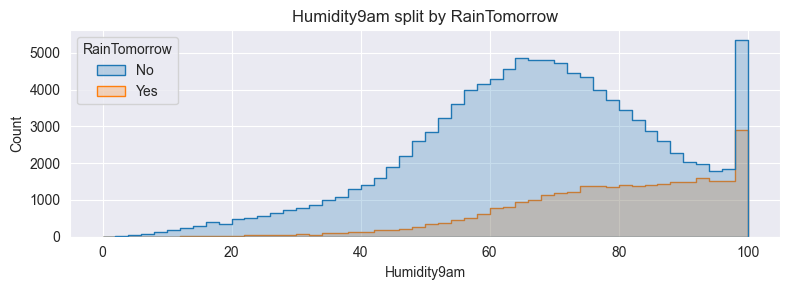

In [104]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda, col='Humidity9am', target='RainTomorrow', bins = 50)

##### Pressure 9am
Pressure9am shows an approximately symmetric and bell-shaped distribution, indicating stable atmospheric pressure conditions in the morning. Missing values are limited, suggesting good data completeness. Only a very small proportion of observations (below 1%) is identified as outliers under the IQR rule, reflecting rare but plausible pressure extremes rather than measurement issues. Overall, morning pressure appears stable and well-suited for direct use in further analysis.

=== Pressure9am (numeric) ===
Rows: 145460
Missing: 15065 (10.4%)

Descriptive statistics:
count    130395.00000
mean       1017.64994
std           7.10653
min         980.50000
25%        1012.90000
50%        1017.60000
75%        1022.40000
max        1041.00000
Name: Pressure9am, dtype: float64

Skewness: -0.10


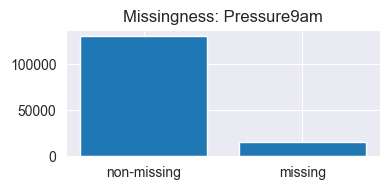

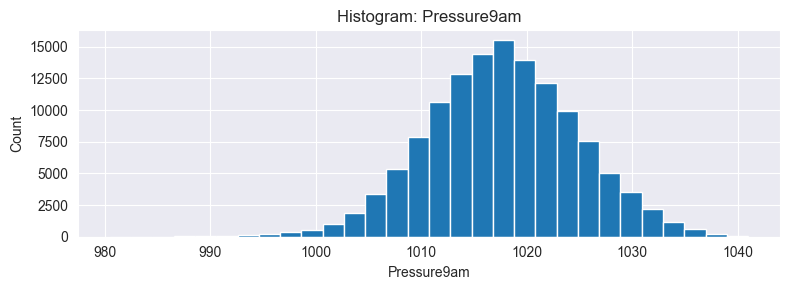

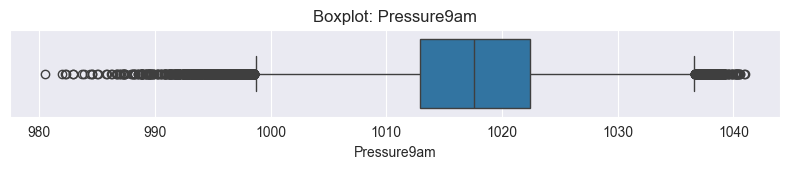

Outliers (IQR rule): 0.8%


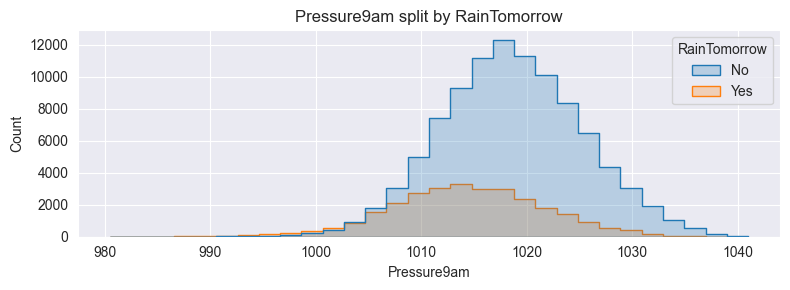

In [105]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda, col='Pressure9am', target='RainTomorrow')

##### Pressure 3pm
Pressure3pm shows an approximately symmetric and bell-shaped distribution, very similar to the morning pressure values. Missing values are limited, indicating good data completeness. Only a small proportion of observations (below 1%) is identified as outliers under the IQR rule, reflecting rare but plausible pressure extremes rather than measurement issues. Overall, afternoon pressure appears stable and well-suited for direct use in further analysis.


=== Pressure3pm (numeric) ===
Rows: 145460
Missing: 15028 (10.3%)

Descriptive statistics:
count    130432.000000
mean       1015.255889
std           7.037414
min         977.100000
25%        1010.400000
50%        1015.200000
75%        1020.000000
max        1039.600000
Name: Pressure3pm, dtype: float64

Skewness: -0.05


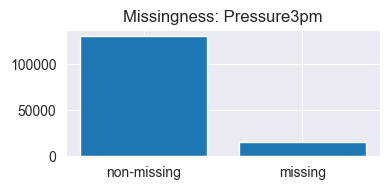

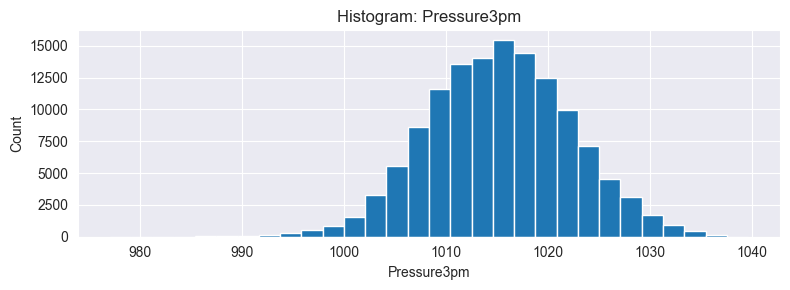

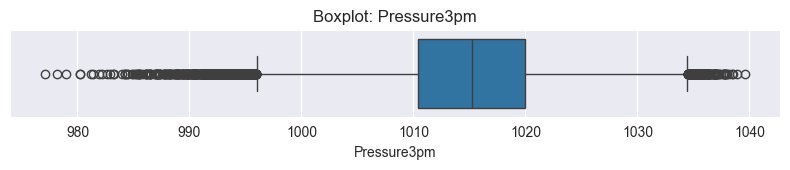

Outliers (IQR rule): 0.6%


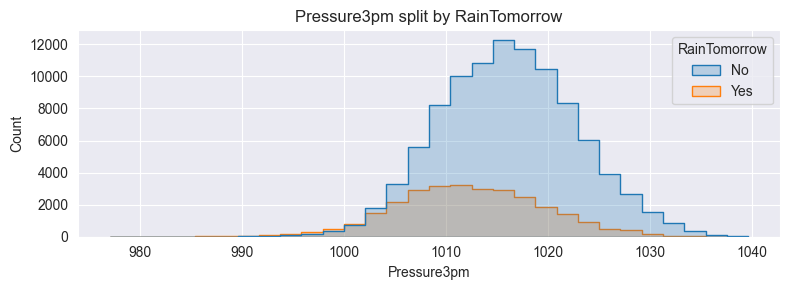

In [108]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda, col='Pressure3pm', target='RainTomorrow')

##### Temperature 9am
Temp9am shows an approximately symmetric and bell-shaped distribution, indicating stable morning temperature conditions. Missing values are minimal, reflecting high data completeness. Only a very small proportion of observations (around 0.2%) is identified as outliers under the IQR rule, corresponding to rare but plausible temperature extremes. Overall, morning temperature appears stable and well-suited for direct use in further analysis.

=== Temp9am (numeric) ===
Rows: 145460
Missing: 1767 (1.2%)

Descriptive statistics:
count    143693.000000
mean         16.990631
std           6.488753
min          -7.200000
25%          12.300000
50%          16.700000
75%          21.600000
max          40.200000
Name: Temp9am, dtype: float64

Skewness: 0.09


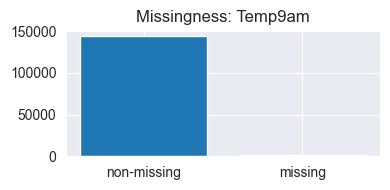

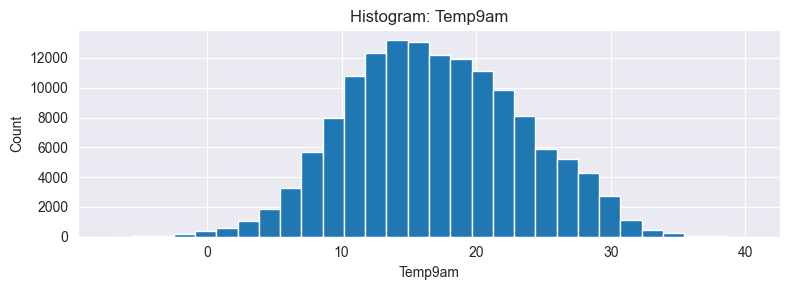

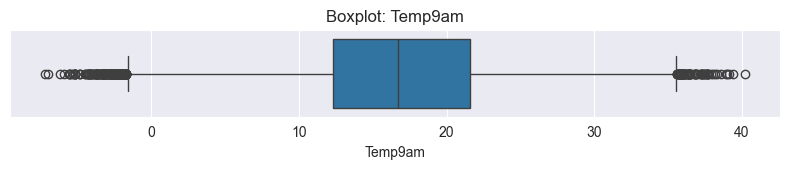

Outliers (IQR rule): 0.2%


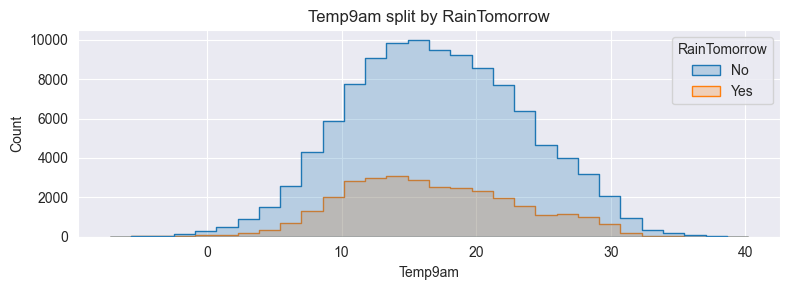

In [107]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda, col='Temp9am', target='RainTomorrow')

##### Temperature 3pm
Temp3pm shows an approximately symmetric and slightly right-skewed distribution, reflecting typical afternoon temperature conditions. Missing values are minimal, indicating high data completeness. Only a very small proportion of observations (around 0.5%) is classified as outliers under the IQR rule, corresponding to rare but plausible temperature extremes. Overall, afternoon temperature appears stable and well-suited for direct use in further analysis.

=== Temp3pm (numeric) ===
Rows: 145460
Missing: 3609 (2.5%)

Descriptive statistics:
count    141851.00000
mean         21.68339
std           6.93665
min          -5.40000
25%          16.60000
50%          21.10000
75%          26.40000
max          46.70000
Name: Temp3pm, dtype: float64

Skewness: 0.24


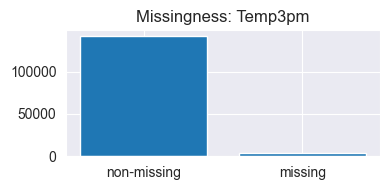

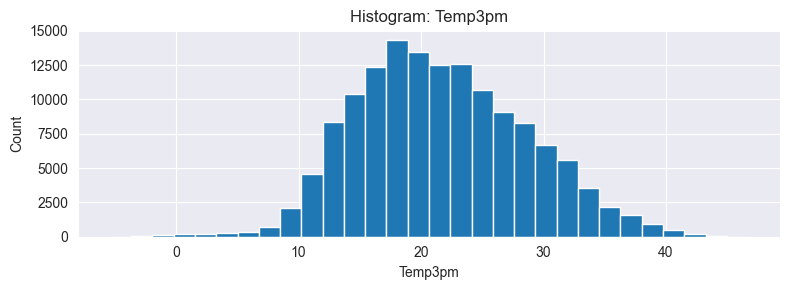

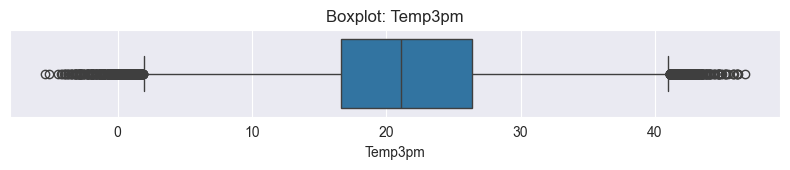

Outliers (IQR rule): 0.5%


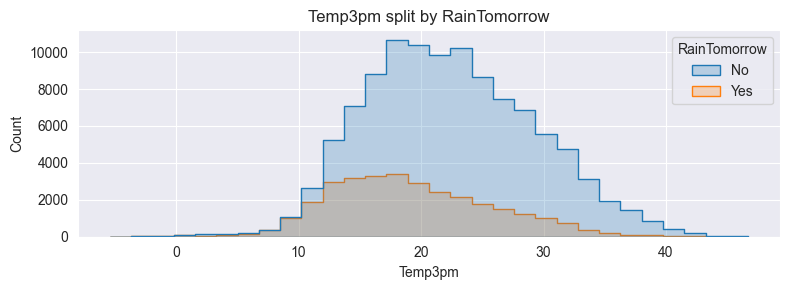

In [106]:
# Nils Becker (03817505)
univariate_report_numerical(df_eda, col='Temp3pm', target='RainTomorrow')

### Bivariate Analysis

##### Rainfall by Location
The spatial visualization reveals a clear geographical pattern in rainfall amount across Australia. Larger bubbles are predominantly concentrated along the coastal regions, particularly in the north, east, and southeast, indicating higher rainfall levels in these areas. In contrast, central and inland regions show fewer and smaller bubbles, reflecting substantially lower precipitation.

This pattern is consistent with Australia’s climatic characteristics, where coastal zones are more strongly influenced by oceanic moisture and weather systems, while the interior remains comparatively try. The map therefore confirms that rainfall is not uniformly distributed but strongly shaped by geographic location and proximity to the coast.

Furthermore, the sensor locations are not evenly distributed across Australia. Observations are clearly clustered along coastal and urban regions, while large parts of the inland, central areas and northwest are sparsely covered or not represented. This suggests that the dataset reflects a measurement density bias, likely driven by population distribution and infrastructure availability, which should be considered when interpreting spatial rainfall patterns.

In [116]:
# Nils Becker (03817505)
# If the geocodes are not loaded properly before, fall back on the local CSV file.
if df_geocodes.empty:
    df_geocodes = pd.read_csv('df_geocodes.csv')

In [117]:
# Nils Becker (03817505)
df_rain_by_location = df_geocodes.copy()

# Drops NaN values for visualization.
df_rain_by_location_clean = df_rain_by_location.dropna(subset=["Latitude", "Longitude"]).copy()

# Normalize Rainfall for scaling.
scaler = MinMaxScaler(feature_range=(4, 30))
df_rain_by_location_clean['Rainfall_norm'] = scaler.fit_transform(df_rain_by_location_clean[['Rainfall']])


# Creates a map with the locations and dynamic bubbles sizes. For that we normalize rainfall.
map_australia = folium.Map(location=[-25.2744, 133.7751], zoom_start=5)

# Creates the bubbles on the map.
for _, row in df_rain_by_location_clean.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=row['Rainfall_norm'],
        fill=True,
        fill_opacity=0.7,
        weight=1,
        popup=f'{row['Location']}<br>Rainfall: {row['Rainfall']:.2f}'
    ).add_to(map_australia)

# Saves the map as HTML file for the presentation.
map_australia.save('rain_by_location.html')

# Shows the map.
map_australia

##### RainTomorrow Rate by Location

In [ ]:
loc_rate = (
    rain_rate_by_category(df_eda, cat_col="Location", top_n=15)
    .sort_values("rain_rate", ascending=False)
)

# plot (helper auto-converts to %)
plot_rate_bar(
    loc_rate,
    x_col="Location",
    rate_col="rain_rate",
    title="RainTomorrow Rate by Location (Top 15)",
    xlabel="Location",
    rotate=45,
)

##### RainTomorrow rate (%) by location

In [ ]:
df_rt_by_location = (
    df_eda[["Location", "RainTomorrow_bin"]]
    .dropna()
    .groupby("Location", as_index=False)["RainTomorrow_bin"]
    .mean()
)
df_rt_by_location["RainTomorrow_pct"] = df_rt_by_location["RainTomorrow_bin"] * 100

df_rt_by_location = df_rt_by_location.merge(
    df_geocodes[["Location", "Latitude", "Longitude"]],
    on="Location",
    how="left",
)

df_rt_by_location_clean = df_rt_by_location.dropna(subset=["Latitude", "Longitude"]).copy()
df_rt_by_location_clean.head()

In [ ]:
# Bubble map (size encodes RainTomorrow rate)
df_map = df_rt_by_location_clean.copy()
df_map["popup"] = df_map.apply(
    lambda r: f"{r['Location']}<br>RainTomorrow: {r['RainTomorrow_pct']:.1f}%",
    axis=1
)

folium_bubble_map(
    df_map,
    lat_col="Latitude",
    lon_col="Longitude",
    size_col="RainTomorrow_pct",
    popup_col="popup",
)

In [ ]:
# Optional: color-encoded markers (fixed radius; color encodes %)
import branca.colormap as cm

colormap = cm.LinearColormap(
    colors=["green", "yellow", "red"],
    vmin=df_rt_by_location_clean["RainTomorrow_pct"].min(),
    vmax=df_rt_by_location_clean["RainTomorrow_pct"].max(),
)
colormap.caption = "RainTomorrow (%)"

m = folium.Map(location=[-25.2744, 133.7751], zoom_start=5)

for _, r in df_rt_by_location_clean.iterrows():
    pct = float(r["RainTomorrow_pct"])
    folium.CircleMarker(
        location=[float(r["Latitude"]), float(r["Longitude"])],
        radius=8,
        color=colormap(pct),
        fill=True,
        fill_color=colormap(pct),
        fill_opacity=0.85,
        popup=f"{r['Location']}<br>RainTomorrow: {pct:.1f}%",
    ).add_to(m)

colormap.add_to(m)
m

##### Rain Tomorrow Rate by Wind

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": "polar"})

polar_rain_rate(axes[0], df_eda, "WindGustDir", WIND_DIR_ORDER, "RainTomorrow Rate by WindGustDir")
polar_rain_rate(axes[1], df_eda, "WindDir9am",  WIND_DIR_ORDER, "RainTomorrow Rate by WindDir9am")
polar_rain_rate(axes[2], df_eda, "WindDir3pm",  WIND_DIR_ORDER, "RainTomorrow Rate by WindDir3pm")

plt.tight_layout()
plt.show()

##### Rain Tomorrow Rate by Rain Today

In [ ]:
tmp = df_eda[["RainToday_bin", "RainTomorrow_bin"]].dropna()

rate_pct = (
    tmp.groupby("RainToday_bin")["RainTomorrow_bin"]
       .mean()
       .reindex([0, 1])
       .mul(100)
)

plt.figure(figsize=(6, 5))
ax = plt.gca()
ax.bar(["No", "Yes"], rate_pct.values)
ax.set_xlabel("RainToday", fontsize=12)
ax.set_ylabel("RainTomorrow rate (%)", fontsize=12)
ax.set_title("RainTomorrow Rate by RainToday", fontsize=14)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, float(rate_pct.max()) * 1.15)

_annotate_min_max_bars(ax, rate_pct.values, fmt="{:.1f}%")

plt.tight_layout()
plt.show()

print("Counts used in plot:")
print(tmp["RainToday_bin"].value_counts())

##### Rain Tomorrow Rate by Cloud

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_cloud_rate(axes[0], df_eda, "Cloud9am", "RainTomorrow Rate by Cloud at 9am")
plot_cloud_rate(axes[1], df_eda, "Cloud3pm", "RainTomorrow Rate by Cloud at 3pm")

axes[0].set_ylabel("RainTomorrow rate (%)", fontsize=12)
plt.tight_layout()
plt.show()

##### RainTomorrow Rate by Numerical Values

In [ ]:
plot_rate_curves_grid(
    df_eda,
    target_col="RainTomorrow_bin",
    q=10,
    n_cols=4,
    figsize=(30, 15),
)

In [ ]:
TOP6_NUM_FEATURES = [
    "Humidity3pm", "Rainfall", "Sunshine",
    "WindGustSpeed", "Pressure9am", "Pressure3pm",
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharey=True)
axes = axes.flatten()

for ax, feat in zip(axes, TOP6_NUM_FEATURES):
    curve = binned_rate_curve(df_eda, feat, target_col="RainTomorrow_bin", q=10)
    plot_rate_curve(ax, curve, feat)

fig.suptitle("RainTomorrow Rate by Key Numerical Features", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Correlation Analysis
Finally different correlation measures were considered, namely Pearson, Spearman, and Kendall correlation coefficients. Pearson correlation was selected as the primary measure because the variables represent continuous physical quantities and the analysis focuses on identifying linear relationships . Spearman and Kendall correlations were evaluated as robustness checks, as they are less sensitive to outliers and capture monotonic associations. However, their rank-based nature reduces interpretability in terms of comparability across variables. The consistency of the observed correlation patterns across all three measures supports the use of Pearson correlation in the exploratory phase.

In [85]:
# Nils Becker (03817505)
cols_for_corr = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
    'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
    'Cloud9am', 'Cloud3pm',
]

df_corr = df_eda[cols_for_corr]

corr_pearson = df_corr.corr(method='pearson')
corr_spearman = df_corr.corr(method='spearman')
corr_kendall = df_corr.corr(method='kendall')

<Axes: title={'center': 'Pearson Correlation'}>

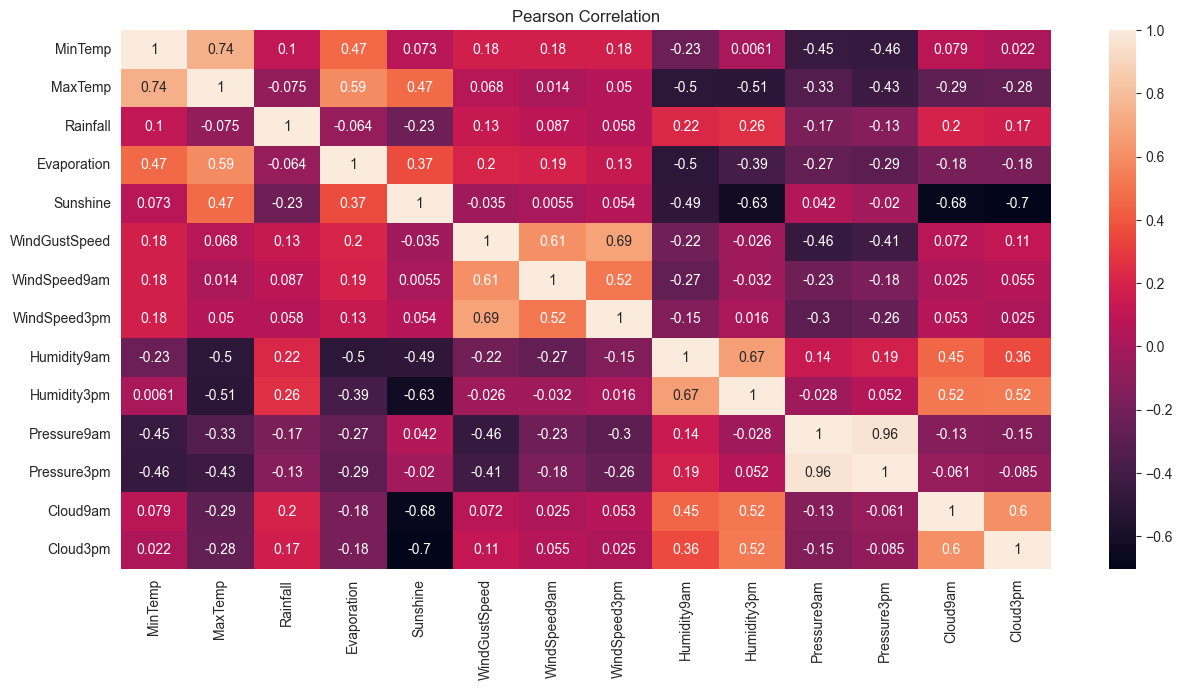

In [89]:
# Nils Becker (03817505)
fig, axes = plt.subplots(figsize=(15,7))
axes.set_title("Pearson Correlation")
sns.heatmap(corr_pearson, annot=True)

For completeness, Spearman and Kendall are listed together.The heatmap reveals strong and positive within-group correlations, such as between temperature variables, wind-related measures, and pressure at different times of day, indicating obvious internal consistency of these groups. In contrast, moisture-related variables, such as humidity and cloud show negative correlations with sunshine and pressure, highlighting atmospheric patterns that are particularly relevant for rainfall-related processes.

For completeness, Spearman and Kendall are listed and combined.

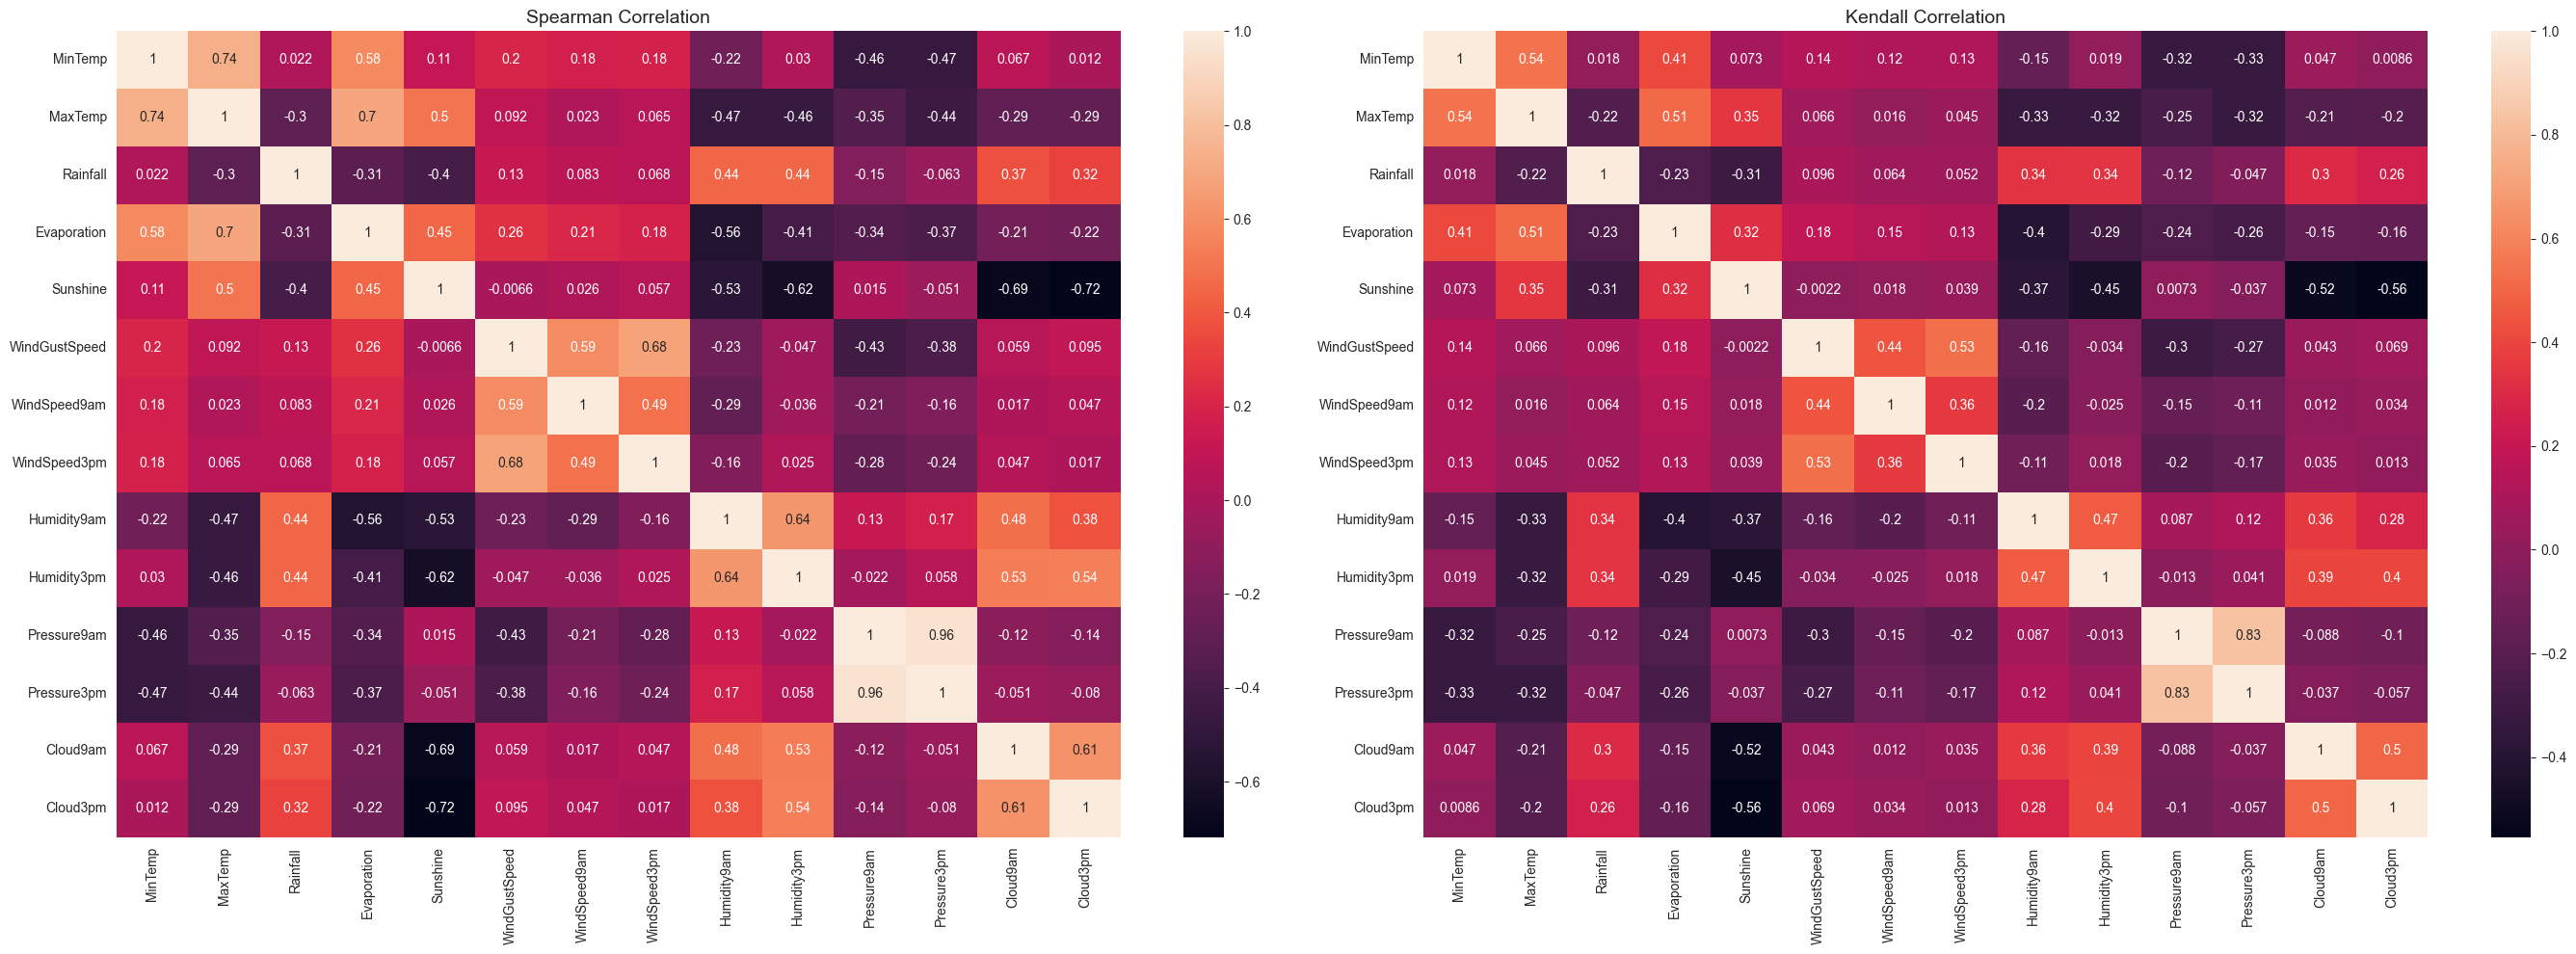

In [90]:
# Nils Becker (03817505)
fig, axes = plt.subplots(1, 2, figsize=(28, 10))

# Spearman
sns.heatmap(corr_spearman, annot=True, ax=axes[0])
axes[0].set_title("Spearman Correlation", fontsize=14)

# Kendall
sns.heatmap(corr_kendall, annot=True, ax=axes[1])
axes[1].set_title("Kendall Correlation", fontsize=14)

plt.tight_layout()
plt.show()

<a id='section4'></a>
## 4. Data Preprocessing


<a id="split-data"></a>
### 4.1 Split Data into Test and Validation Sets

#### Preliminary Operations: Data Reloading, Feature Engineering, and High-Cardinality Categorical Feature Handling

In [ ]:
# Reloading Data
df = pd.read_csv('weatherAUS.csv')
# Converting date to datetime format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.weekday
df = df.drop(columns=["Date"])
# Converting Cloud columns to object data types
df[['Cloud9am', 'Cloud3pm']] = df[['Cloud9am', 'Cloud3pm']].astype('object')
# Dropping rows with missing target values
df = df.dropna(subset=['RainTomorrow']).copy()

# Detect nominal features with high-cardinality
HIGH_CARDINALITY_THRESHOLD = 10
high_card_features = [
    (col, df[col].nunique())
    for col in nominal_categorical_features
    if df[col].nunique() > HIGH_CARDINALITY_THRESHOLD
]

# Separate low/high-cardinality nominal columns
low_card_features = [col for col in categorical_features if col not in [c for c, _ in high_card_features]]
high_card_features_names = [col for col, _ in high_card_features]

print("High-cardinality features:", high_card_features_names)
print("Low-cardinality features: ",low_card_features)

We first reloaded and preprocessed the raw data. We used pd.read_csv('weatherAUS.csv') to load the dataset, converted Date to datetime format (with errors="coerce" to avoid errors caused by invalid dates), and extracted four time features from it, including Year, Month, Day, and Weekday, to capture possible seasonal and periodic effects. Then we dropped the original Date column to reduce redundancy. At the same time, we explicitly converted Cloud9am and Cloud3pm to the object type so that they would be treated as categorical variables and encoded as such in later steps. We also removed samples with missing target values in RainTomorrow to ensure the labels are complete for supervised learning.

Next, to avoid a very large feature space caused by One-Hot encoding on nominal categorical variables, we set a high-cardinality threshold HIGH_CARDINALITY_THRESHOLD = 10 and grouped nominal categorical features based on the number of unique values. If a feature has nunique() > 10, we treat it as a high-cardinality feature. The results show that the high-cardinality features are ['Location', 'WindGustDir', 'WindDir3pm', 'WindDir9am'], and the low-cardinality features are ['Cloud9am', 'Cloud3pm', 'RainToday']. This grouping supports our later encoding strategy. Low-cardinality features are suitable for One-Hot or ordinal encoding, while high-cardinality features are better handled with Target Encoding. In this way, we can control the feature dimension while keeping useful information, and also improve training efficiency and model stability.

#### Splitting data

In [ ]:
# Dropping missing values, as it lead to better model performance in preliminary experiments
df_clean = df.dropna().reset_index(drop=True)

# Define features matrix X and target vector y
y = df_clean[target]
X = df_clean.drop(columns=[target])

# First split into (train + val) and test sets - 80% (train + val), 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # or use stratify=y because target is categorical/imbalanced
)

# Then split again (train + val) into train and validation sets - 75% train, 25% val of remaining 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 of original data for validation
    random_state=42,
    stratify=y_train_val
)


print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Before splitting the data, we chose a drop-missing strategy based on our pilot results. We applied df.dropna() to the full dataset and reset the index (reset_index(drop=True)) to obtain a clean dataset df_clean without missing values. Then we extracted the target variable RainTomorrow as the label vector y, and used all remaining columns as the feature matrix X.

For dataset splitting, we used a two-step stratified split to handle the class imbalance issue. In the first step, we split the data into 80% (train+val) and 20% (test), where test_size = 0.2 and stratify = y ensure that the “rain / no rain” ratio in the training and test sets is consistent with the overall dataset. We also set random_state = 42 for reproducibility. In the second step, we further split the 80% train+val part into 75% (train) and 25% (validation), which correspond to 60% / 20% of the original dataset. We again used stratify = y_train_val to keep the class ratio stable.

Finally, the dataset sizes are Train = 33,852, Validation = 11,284, and Test = 11,284. This splitting strategy keeps training, tuning, and final generalization evaluation independent, and stratified sampling improves the reliability of evaluation under an imbalanced classification setting.

### 4.2 Encoding Target

In [ ]:
# Target Encoding (with index reset to avoid misalignment)

# ⚠️ IMPORTANT:
# After train/val/test split, X and y keep their original dataframe indices.
# Example:
#   X_train.index → [5, 7, 10, 11, ...]
#   y_train.index → [5, 7, 10, 11, ...]
#
# But when we encode y using LabelEncoder, it becomes a NumPy array:
#   y_train_encoded → [0, 1, 0, 0, ...]
#
# NumPy arrays do NOT keep the original indices.
# This causes X and y to become MISALIGNED during cross‑validation.
# Models then learn from the wrong labels → predict only zeros → F1 = NaN.
#
# ✔ Fix: reset indices BEFORE encoding so X and y stay aligned by position.

X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# Encode the target AFTER resetting indices

def encode_target(y):
    """
    Encode target labels ('Yes'/'No') into integers (0/1).
    Returns:
        - encoded labels (NumPy array)
        - fitted LabelEncoder (so we can transform val/test consistently)
    """
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    return y_encoded, le

# Fit encoder on TRAIN ONLY (to avoid leakage)
y_train_encoded, target_encoder = encode_target(y_train)

# Apply the SAME encoder to validation and test sets
y_val_encoded  = target_encoder.transform(y_val)
y_test_encoded = target_encoder.transform(y_test)

# Optional sanity check: confirm mapping
print("Label mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))


After splitting the dataset into training, validation, and test sets, we first applied reset_index(drop=True) to X_train, X_val, X_test and the corresponding y_train, y_val, y_test. This ensures that features and labels stay strictly aligned by row order in later modeling steps, especially during cross-validation and operations such as cross_val_predict. This is important because pandas objects usually keep the original index after splitting, while later encoding or transformations may produce NumPy arrays without an index. If we do not reset the index, X and y can become misaligned, which may cause the model to learn incorrect labels and lead to abnormal results (for example, predicting all zeros or getting an unusual F1 score).

Next, we defined an encode_target(y) function and used LabelEncoder to convert the target labels from strings ('Yes'/'No') into binary integers (0/1). The function also returns the fitted encoder so that we can apply the same mapping to validation and test sets. To avoid information leakage, we followed the rule of fitting the encoder only on the training set. We first applied fit_transform on y_train to get y_train_encoded, and then used the same target_encoder to apply transform on y_val and y_test. This guarantees that all three sets use exactly the same encoding rule.

Finally, we printed the label mapping to check consistency. The output was {'No': 0, 'Yes': 1}, which clearly encodes “no rain” as 0 and “rain” as 1. This also provides a consistent standard for computing metrics such as F1, Precision, and Recall with the positive class defined as Yes = 1.

### 4.3 Features Preprocessing 

#### Checking Best Imputation Streategies for Numerical Features and Outlier Management
> Tested on train set only, using LightGBM and cross validation.

In [ ]:
# Helper functions for outlier handling

def remove_outliers_zscore(df, features, threshold=3):
    df_clean = df.copy()
    z_scores = np.abs(stats.zscore(df_clean[features], nan_policy='omit'))
    mask = (z_scores < threshold).all(axis=1)
    return df_clean[mask]

def cap_outliers_iqr(df, features):
    df_clean = df.copy()
    for col in features:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean[col] = df_clean[col].clip(lower, upper)
    return df_clean

def isolation_forest_filter(df, features):
    iso = IsolationForest(contamination=0.02, random_state=42)
    mask = iso.fit_predict(df[features]) == 1
    return df[mask]

# Build preprocessing pipeline generator

def build_preprocessor(impute_strategy):
    
    # Numeric transformer
    if impute_strategy == "mean":
        num_imputer = SimpleImputer(strategy='mean')
    else:
        num_imputer = SimpleImputer(strategy='median')

    numeric_transformer = Pipeline([
        ('imputer', num_imputer),
        ('scaler', StandardScaler())
    ])

    # Ordinal transformer
    ordinal_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)) #avoid crash if unknown category
    ])

    # Low-cardinality nominal
    low_card_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # High-cardinality nominal
    high_card_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder())
    ])

    transformers = [
        ('num', numeric_transformer, numerical_features),
        ('ord', ordinal_transformer, ordinal_categorical_features)
    ]

    if low_card_features:
        transformers.append(('low_card', low_card_transformer, low_card_features))

    if high_card_features_names:
        transformers.append(('high_card', high_card_transformer, high_card_features_names))

    return ColumnTransformer(transformers=transformers)

# Experiment runner

def evaluate_strategy(X_train, y_train, impute_strategy, outlier_strategy):

    # --- Outlier handling ---
    if outlier_strategy == "none":
        X_clean = X_train.copy()
        y_clean = y_train.copy()

    elif outlier_strategy == "zscore":
        df = X_train.copy()
        df["target"] = y_train
        df = remove_outliers_zscore(df, numerical_features)
        y_clean = df["target"]
        X_clean = df.drop(columns=["target"])

    elif outlier_strategy == "iqr":
        df = X_train.copy()
        df["target"] = y_train
        df = cap_outliers_iqr(df, numerical_features)
        y_clean = df["target"]
        X_clean = df.drop(columns=["target"])

    elif outlier_strategy == "isolation_forest":
        df = X_train.copy()
        df["target"] = y_train
        df = isolation_forest_filter(df, numerical_features)
        y_clean = df["target"]
        X_clean = df.drop(columns=["target"])

    # --- Missing value handling ---
    if impute_strategy == "drop":
        df = X_clean.copy()
        df["target"] = y_clean
        df = df.dropna()
        y_clean = df["target"]
        X_clean = df.drop(columns=["target"])
        preprocessor = build_preprocessor("median")
    else:
        preprocessor = build_preprocessor(impute_strategy)
    
    fast_lgbm = LGBMClassifier(
        n_estimators=200,        # still fast, but more stable than 50
        learning_rate=0.05,     # small LR for stability
        max_depth=-1,           # let LGBM choose optimal depth
        num_leaves=31,          # default, fast and robust
        subsample=0.8,          # row sampling for speed
        colsample_bytree=0.8,   # feature sampling for speed
        n_jobs=-1,              # use all CPU cores
        random_state=42,
        force_row_wise=True # avoids feature-name checks
    )

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', fast_lgbm) # Faster than RandomForest
    ])

    # --- Cross-validation ---
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Only ONE cross_val_predict call
    probas = cross_val_predict(model, X_clean, y_clean, cv=cv, method="predict_proba")
    preds = (probas[:, 1] >= 0.5).astype(int)

    y_binary = y_clean

    metrics = {
        "F1": f1_score(y_binary, preds),
        "Precision": precision_score(y_binary, preds),
        "Recall": recall_score(y_binary, preds),
        "BalancedAccuracy": balanced_accuracy_score(y_binary, preds),
        "ROC_AUC": roc_auc_score(y_binary, probas[:, 1])
    }

    return metrics


# Run all experiments

imputation_methods = ["mean", "mode", "drop"]
outlier_methods = ["none", "zscore", "iqr", "isolation_forest"]

results = []

for imp in imputation_methods:
    for out in outlier_methods:
        metrics = evaluate_strategy(X_train, y_train_encoded, imp, out)
        results.append({
            "Imputation": imp,
            "Outliers": out,
            **metrics
        })

results_df = pd.DataFrame(results)
results_df


#### **Summary of Results**

The cross‑validation experiments show that the choice of imputation strategy has a noticeable impact on model performance, with **dropping rows containing missing values** consistently outperforming both mean and mode imputation. Because the dataset is large, removing incomplete rows does not significantly reduce training size, and it avoids introducing noise or bias from imputed values. This leads to the highest F1‑scores (≈0.65), the strongest balanced accuracy (≈0.76), and the best ROC‑AUC values (≈0.90), making it the most effective approach for this task.

Outlier handling has a smaller effect overall. Both **no outlier removal** and **IQR capping** produce similar and strong results, while **Isolation Forest consistently reduces performance**, likely because it removes legitimate extreme weather observations that are important for predicting rainfall. Mean and mode imputation behave similarly across all outlier strategies, confirming that LightGBM is robust to moderate noise in the input features.

Overall, the best preprocessing configuration for predicting *RainTomorrow* is to **drop missing rows and avoid aggressive outlier removal**, allowing the model to learn from clean, representative data without discarding meaningful variability. This combination provides the strongest generalization performance across all evaluated metrics.

#### Features Preprocessing

In [ ]:
# --- Define transformers ---

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

low_card_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

high_card_transformer = Pipeline([
    ('encoder', TargetEncoder())
])

transformers = [
    ('num', numeric_transformer, numerical_features),
    ('ord', ordinal_transformer, ordinal_categorical_features)
]

if low_card_features:
    transformers.append(('low_card', low_card_transformer, low_card_features))

if high_card_features_names:
    transformers.append(('high_card', high_card_transformer, high_card_features_names))

preprocessor = ColumnTransformer(transformers=transformers)

<a id='section5'></a>
## 5. Model Selection and Hyperparameter Tuning


### 5.1 Models Definition

> Explain model choices.

In [ ]:
# Create model dictionary
models = {}

# Random Forest (classification)
models["Random Forest"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Logistic Regression
models["Logistic Regression"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver='saga',
        multi_class='multinomial',
        C=1.0,
        random_state=42
    ))
])

# LightGBM
models["LightGBM"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ))
])

# Deep Learning Model (MLPClassifier)
models["Neural Network (MLP)"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=0.001,
        max_iter=50,              # keep small for speed
        random_state=42
    ))
])

# Ensemble Model (Stacking)
stack_estimators = [
    ("rf", RandomForestClassifier(n_estimators=150, random_state=42)),
    ("lgbm", LGBMClassifier(n_estimators=150, learning_rate=0.05, random_state=42)),
]

models["Stacking Ensemble"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", StackingClassifier(
        estimators=stack_estimators,
        final_estimator=LogisticRegression(max_iter=2000),
        n_jobs=-1
    ))
])


### 5.2 Model Hyperparameter Tuning

In [ ]:
# ---------------------- Hyperparameter grids ----------------------
param_grids = {
    # Random Forest
    "Random Forest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [10, 20, None],
        "clf__max_features": ["sqrt", "log2"],
        "clf__min_samples_split": [2, 5],
        "clf__min_samples_leaf": [1, 3]
    },

    # LightGBM
    "LightGBM": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.05, 0.1],
        "clf__num_leaves": [20, 31, 50],
        "clf__max_depth": [-1, 5, 10],
        "clf__subsample": [0.7, 0.9],
        "clf__colsample_bytree": [0.7, 0.9]
    },

    # Logistic Regression
    "Logistic Regression": {
        "clf__C": [0.1, 1, 3],
        "clf__penalty": ["l2"],
        "clf__solver": ["saga"],
        "clf__max_iter": [2000]
    },

    # Neural Network (MLP)
    "Neural Network (MLP)": {
        "clf__hidden_layer_sizes": [(64, 32), (128, 64)],
        "clf__activation": ["relu"],
        "clf__alpha": [1e-4, 1e-3],
        "clf__learning_rate_init": [0.001, 0.01],
        "clf__max_iter": [50]   # keep small for speed
    },

    # Stacking Ensemble
    "Stacking Ensemble": {
        # Only tune the final estimator to keep runtime reasonable
        "clf__final_estimator__C": [0.1, 1, 3],
        "clf__final_estimator__penalty": ["l2"]
    }
}


In [ ]:
# ---------------------- Hyperparameter tuning ----------------------

# F1 scorer for the positive class ("Yes" encoded as 1)
f1_scorer = make_scorer(
    f1_score,
    pos_label=1,
    zero_division=0
)

best_models = {}
best_params = {}          # <--- store raw best params
clean_best_params = {}    # <--- store only clf__ parameters
cv_results = []

for name, pipeline in models.items():
    print(f"\n--- Tuning {name} ---")

    param_grid = param_grids.get(name, {})

    if not param_grid:
        print(f"No hyperparameter grid defined for {name}, skipping.")
        continue

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring=f1_scorer,
        cv=5,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train_encoded)

    # Store tuned model
    best_models[name] = search.best_estimator_

    # Store raw best params
    best_params[name] = search.best_params_

    # Extract only classifier parameters (remove preprocess params)
    clean_best_params[name] = {
        k.replace("clf__", ""): v
        for k, v in search.best_params_.items()
        if k.startswith("clf__")
    }

    print(f"Best params for {name}: {search.best_params_}")
    print(f"Best CV F1 for {name}: {search.best_score_:.4f}")

    # Evaluate on validation set
    y_pred_val = search.predict(X_val)

    metrics = evaluate_model(
        model_name=name,
        y_true=y_val_encoded,
        y_pred=y_pred_val,
    )

    cv_results.append(metrics)

After finishing hyperparameter tuning and validation evaluation for all models, we summarized the validation results of each candidate model into a DataFrame. We then sorted the results by positive-class F1 as the main selection criterion and chose the model with the highest F1 score as the final model. Specifically, the code converts cv_results into a table and ranks models in descending order of F1. Next, it extracts the top-ranked model name and retrieves the corresponding best Pipeline from best_models. This Pipeline contains the unified preprocessor and the tuned classifier.

Finally, the code prints the best model name and its full parameter settings, including both preprocessing settings and classifier hyperparameters. This supports experiment logging and result reproducibility, and it provides a fixed model basis for the later steps, including retraining on the merged Train+Val data and the final evaluation on the test set. The output shows: “=== Best model selected: LightGBM ===”, which means LightGBM achieved the highest validation F1 and was chosen as the final model.

In [ ]:
"""
# Create a clean DataFrame of best classifier parameters for each model
clean_params_df = pd.DataFrame([
    {"Model": model_name, **params}
    for model_name, params in clean_best_params.items()
])

clean_params_df
"""

<a id='section6'></a>
## 6. Final Models Training & Evaluation

In [ ]:
# ---------------------- Retrain all best models on train + val ----------------------

X_train_val = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_train_val_encoded = np.concatenate([y_train_encoded, y_val_encoded])

final_test_results = []

for name, model in best_models.items():
    print(f"\n=== Retraining {name} on train + val ===")
    
    # Fit model on combined training data
    model.fit(X_train_val, y_train_val_encoded)
    
    # Evaluate on test set
    y_pred_test = model.predict(X_test)
    
    metrics = evaluate_model(
        model_name=name,
        y_true=y_test_encoded,
        y_pred=y_pred_test
    )
    
    final_test_results.append(metrics)


In [ ]:
final_results_df = pd.DataFrame(final_test_results).sort_values("F1", ascending=False)
final_results_df

We finally selected LightGBM as the best model for this project and combined it with a unified feature preprocessing pipeline (Pipeline + ColumnTransformer). This setup keeps feature processing consistent across the training, validation, and test stages, including numeric standardization, One-Hot encoding for low-cardinality categorical features, Target Encoding for high-cardinality categorical features, and ordinal encoding for ordered categorical features. As a result, the workflow improves reproducibility and reduces the risk of data leakage. After deciding the best model and hyperparameters, we merged the training and validation sets (Train+Val) and retrained the final model, then conducted a one-time generalization evaluation on an independent test set.

The final model achieved F1 = 0.6483, Precision = 0.7574, Recall = 0.5666, and Balanced Accuracy = 0.7577 on the test set. The relatively high Precision indicates that the model is cautious when predicting “rain tomorrow,” so it produces fewer false alarms. However, Recall is still at a medium level, which means there is still room to reduce missed rainy cases. This is a common trade-off in imbalanced classification tasks. The model comparison and tuning results also suggest that LightGBM can capture non-linear relationships and feature interactions more effectively on this tabular weather dataset. Therefore, its overall performance is better than, or close to, other candidate models (Random Forest, Logistic Regression, MLP, and Stacking), and its performance remains stable on the test set.

<a id='section7'></a>
## 7. Feature Importance / Explainability


In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Scorer for permutation importance
f1_scorer = make_scorer(f1_score, pos_label=1, zero_division=0)

# Dictionary to store importance results for each model
all_importances = {}

for name, model in best_models.items():
    print(f"\n=== Permutation Importance for {name} ===")

    # Compute permutation importance on the TEST set
    perm = permutation_importance(
        estimator=model,          # full pipeline (preprocessing + model)
        X=X_test,
        y=y_test_encoded,
        scoring=f1_scorer,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    # Convert to DataFrame
    fi_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance_Mean": perm.importances_mean,
        "Importance_Std": perm.importances_std
    }).sort_values("Importance_Mean", ascending=False)

    all_importances[name] = fi_df

    print(fi_df.head(15))

    # Plot Top-15 features
    import matplotlib.pyplot as plt
    import numpy as np

    top_k = 10

    # Use a rainbow-style colormap
    cmap = plt.cm.rainbow   # or plt.cm.gist_rainbow
    colors = cmap(np.linspace(0, 1, top_k))

    plt.figure(figsize=(8, 6))

    plt.barh(
        fi_df["Feature"].head(top_k)[::-1],
        fi_df["Importance_Mean"].head(top_k)[::-1],
        color=colors[::-1]   # reverse so colors match feature order
    )

    plt.xlabel("Permutation Importance (ΔF1)")
    plt.ylabel("Feature")
    plt.title(f"Top {top_k} Feature Importances for {name} (Permutation, Test Set)")
    plt.tight_layout()
    plt.show()

#### **Model choice**
The key idea of Permutation Importance is: on the test set, we randomly shuffle one feature column (so the link between this feature and the target is broken), and then we observe how much the model performance drops (in this study, we use F1 for the positive class). A larger drop means the model depends more on this feature, so the feature is more important. This method works on the full Pipeline, so it can output feature importance for the original feature columns while keeping preprocessing consistent. This makes the results easier to interpret and compare.

#### **Experiment setup**
We use the test set for evaluation and use the best LightGBM Pipeline that is retrained on Train + Val. Since “rain tomorrow” is usually the minority class, F1 can better reflect the detection quality for rainy days, so we use ΔF1 as the evaluation metric. We set n_repeats = 10. For each feature, we repeat the permutation 10 times and take the average to reduce fluctuations caused by randomness.

#### **Result analysis**
The figure shows the top 15 features by permutation importance on the test set. Humidity3pm is much more important than all other variables. This means that shuffling only the Humidity3pm column causes the model’s F1 to drop by about 0.20 on average. It shows that the model strongly depends on “humidity at 3 pm” to predict the probability of rain on the next day. From a meteorology view, humidity directly reflects the amount of water vapor. Humidity in the afternoon can reflect cloud and rain development later in the day and how close the air is to saturation, so it provides a strong signal for predicting next-day rainfall.

Sunshine and Pressure3pm also have strong explanatory power. Shorter sunshine hours usually mean thicker clouds and less solar radiation, which is closely related to a higher chance of rainfall. The importance of Pressure3pm is clearly higher than Pressure9am, which suggests the model relies more on “afternoon pressure” as a signal of changes in the weather system. Low-pressure systems are often linked with rising air and unstable weather, which are important background conditions for rainfall.

WindGustSpeed, Cloud3pm, Rainfall, and Location show medium importance, and all are clearly above 0. This means they still make real contributions to model performance. WindGustSpeed can reflect the strength of the weather system and how active convection is, and it is often related to fronts and low-pressure systems. Cloud3pm directly describes cloud cover and is closely connected to the rainfall formation process. Rainfall represents today’s rainfall amount and can act as prior information for rain continuation. If it rains today, the chance of rain tomorrow often increases. Location is converted by Target Encoding into a continuous value related to rainfall rate, which captures regional climate differences (for example coastal vs inland, or different climate zones). Therefore, it provides a stable gain for prediction.

#### **Robustness analysis**
The standard deviation of importance for the top features is generally small (about 0.001 to 0.004). This shows that under 10 repeated permutations, the importance estimates are stable, so the conclusions are reliable. In particular, Humidity3pm, Sunshine, and Pressure3pm have both high mean importance and low variation, which suggests they contribute consistently and robustly to the model’s predictions.

<a id='section8'></a>
## 8. Conclusions & Next Steps

#### **Summary of overall process**
This project builds a binary classification framework to predict RainTomorrow (whether it will rain tomorrow) based on historical weather observations in Australia. The overall workflow has five stages: **EDA** → **data processing and feature engineering** → **modeling and tuning** → **final evaluation** → **interpretability analysis**.
##### 1.**EDA**
In the EDA stage, we systematically checked data quality and distribution patterns, including the class ratio of the target, missing value patterns, distributions and skewness of key weather features (such as humidity, pressure, sunshine, and rainfall), relationships between variables and the target, and differences across categorical features such as Location. The main EDA findings guided later modeling. For example, the dataset has clear missing values (especially in some weather variables), so we needed a clear missing-value strategy. The target class (**RainTomorrow**) is somewhat imbalanced, so evaluation should focus on **F1, Recall, and Balanced Accuracy**. Variables like humidity, pressure, sunshine, and cloud cover are strongly related to rainfall. Location reflects regional climate differences and is a high-cardinality categorical feature, so it needs proper encoding.
##### 2.**Data cleaning and feature engineering**
After loading the data, we decomposed the date into time features such as **Year, Month, Day, and Weekday**. We set cloud-related variables as categorical features and removed samples with missing target values. Then we identified high-cardinality categorical features (such as Location and wind directions) and low-cardinality categorical features (such as RainToday and some cloud-related variables), and designed the encoding strategy based on this.
##### 3.**Data splitting and target encoding**
We used stratified sampling to split the data into **Train, Validation, and Test sets**. Before target encoding, we reset the index to avoid misalignment between features and labels during cross-validation, which helps ensure reliable evaluation.
##### 4.**Preprocessing pipeline and model comparison**
We built a unified preprocessing pipeline using **Pipeline + ColumnTransformer**, including numeric standardization, One-Hot encoding for low-cardinality features, Target Encoding for high-cardinality features, and ordinal encoding for ordered categorical variables. Under this unified input setting, we trained and compared several models, including **Random Forest, Logistic Regression, LightGBM, MLP, and Stacking**.
##### 5.**Hyperparameter tuning, final training, and test evaluation**
We used RandomizedSearchCV (5-fold cross-validation, optimizing positive-class F1) for tuning and selected the best model based on validation results. The final model is LightGBM. After retraining it on the combined Train+Val data, we achieved the following results on the test set: **F1 = 0.652, Precision = 0.765, Recall = 0.567, Balanced Accuracy = 0.759**.
##### 6.**Interpretability analysis**
On the test set, we used permutation importance (ΔF1) to evaluate feature importance. The results show that **Humidity3pm, Sunshine, and Pressure3pm** are the most important features, and this is consistent with the weather patterns observed in the EDA stage.

#### **What worked well**
##### 1.**EDA guided our modeling decisions like a “navigation tool”**
EDA helped us identify the main challenges in the data, including missing values, class imbalance, and high-cardinality categorical features. It also highlighted strong signal variables such as humidity, pressure, sunshine, and cloud cover. Based on these findings, we made several key decisions. We used a more robust missing-value strategy (finally choosing dropna or a robust imputation approach). We focused on metrics that fit imbalanced data better, such as positive-class F1 and Balanced Accuracy. We also applied Target Encoding to high-cardinality features like Location to avoid a large feature space caused by One-Hot encoding.

##### 2.**LightGBM performed best on this tabular task and generalized well**
After hyperparameter tuning, LightGBM achieved the highest cross-validation F1 score, and its test performance stayed at a similar level (F1 about 0.652). This suggests the model is stable and works well on unseen data.

##### 3.**A unified preprocessing Pipeline improved fairness, reproducibility, and reduced leakage risk**
By wrapping preprocessing and the model into one Pipeline, we ensured that cross-validation and test evaluation followed the same process. This reduces bias caused by manual differences and also lowers the risk of data leakage.

##### 4.**Interpretability results matched the EDA observations and increased trust in the model**
Permutation importance shows that Humidity3pm (ΔF1 about 0.204) is the most important feature by a large margin, followed by Sunshine and Pressure3pm. This is consistent with the EDA findings that humidity, pressure, and sunshine are strongly related to rainfall. This agreement suggests the model learned reasonable patterns and makes the results more trustworthy.

#### **Project limitations and improvements**
##### 1.**Class imbalance still limits Recall**
Although Precision is high (0.765), Recall is 0.567. This means the model still misses some rainy days. In risk-sensitive settings, this may require further improvement. 

**Action**: Add imbalance handling in LightGBM, such as scale_pos_weight = (#negative / #positive) or is_unbalance = True, to increase the learning focus on the positive class.

##### 2.**Random splitting may underestimate the difficulty of time generalization**
Weather data has clear seasonality and time dependence. A random split may make the training and test sets too similar, so the evaluation can be too optimistic.  

**Action**: Use TimeSeriesSplit for cross-validation and report performance changes across different time folds. Maybe can also add seasonal feature interactions (such as Month × Location) and check whether they improve stability across years.

##### 3.**Permutation importance alone cannot explain the direction of effects**
Permutation importance can show whether a feature is important, but it cannot directly tell whether a higher feature value increases or decreases the rain probability. Also, correlated features can replace each other, which may make importance values look smaller.  

**Action**: Add SHAP analysis (both global and local) to provide direction and contribution explanations.